# **프로젝트: 도로 영역을 찾는 세그멘테이션 모델 만들기**


#### **1. 프로젝트 목적:**
U-Net / U-Net++ v1 / U-Net++ v2 세 가지 세그멘테이션 모델을 KITTI 데이터셋으로 학습시켜 도로 영역을 픽셀 단위로 검출하고, 모델 간 성능을 정량과 정성 두 기준으로 비교하여 자율주행 도로 인식에 가장 적합한 모델을 선정한다.

#### **2. 데이터셋: [KITTI Object Detection](https://www.cvlibs.net/datasets/kitti/) 🚗**
   - 자율주행 연구를 위해 독일 카를스루에에서 수집한 도로 주행 이미지 벤치마크 데이터셋
   - 총 이미지 14,999장 / 학습 이미지 7,481장 / 총 객체 51,865개 / 9 개 클래스
     (Car, Van, Truck, Pedestrian, Person_sitting, Cyclist, Tram, Dont care, Misc)
   - 각 객체에 2D 바운딩 박스, truncated(0-1 `float`), occluded(0-3 `int`) 속성 포함
   - ImageNet 사전 학습 정규화(mean/std) 및 384×640 리사이즈 적용

#### **3. 모델**
도로 픽셀을 이진 마스크로 예측하는 인코더-디코더 구조를 지닌 세 가지 모델을 비교한다.  

- **U-Net:** 4단계 Encoder-Decoder + 단일 Skip Connection

- **U-Net++ v1:** Dense Skip Connection + Deep Supervision (4출력 평균)

- **U-Net++ v2:** U-Net++ v1 + 업샘플 직후 1×1 Conv 채널 정렬 (Re-designed Decoder)

공통 설정: filters = [64, 128, 256, 512, 1024], Dropout(0.5) at Bottleneck, Adam(lr=1e-4), 100 epoch


#### **4. 평가 지표**

##### **4-1. 정량적 평가**

- IoU: 예측-정답 전체 중첩 성능

- Precision: 도로라고 한 것 중 실제 도로 비율 (낮으면 비도로 자주 침범)

- Recall: 실제 도로 중 잡아낸 비율 (낮으면 주행 가능 영역 손실)

- F1: Precision-Recall 균형

- Boundary IoU: 경계 픽셀(3px)만 추출한 IoU


##### **4-2. 정성적 평가**

- Val set 오류 맵: 라벨 있는 val 이미지에서 TP(초록) / FP(빨강) / FN(파랑)을 컬러로 구분해 모델별 오류 패턴 비교

- Test set 오버레이: 라벨 없는 test 이미지에 예측 마스크를 반투명 오버레이로 시각화


#### **5. 핵심 과제:**

- 논문 기반 U-Net ++ v1, v2 구현

- 도로 픽셀 불균형 문제 해결 (Weighted BCE + 데이터 증강)

- 도로 경계 정밀도 향상 (Boundary IoU 측정 및 Dense Skip Connection 효과 검증)

<br><br/>
*본 코드 파일은 26/02/27 코드 리뷰 후 수정한 버전임

## 1. 라이브러리 및 경로 설정

In [1]:
import os
import math
import time
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision.transforms as transforms

from PIL import Image
import matplotlib.pyplot as plt
from skimage.io import imread
from skimage.transform import resize
from glob import glob
from torch.utils.data import Dataset, DataLoader
from torchinfo import summary
from albumentations import HorizontalFlip, RandomSizedCrop, Compose, OneOf, Resize

print(torch.__version__)

2.7.1+cu118


In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')  # 디바이스 설정
print(f"device: {device}")

device: cuda


In [3]:
# 경로 설정
HOME           = os.getenv('HOME')
SAVE_DIR       = os.path.join(HOME, 'work/semantic_segmentation')
DATA_DIR       = os.path.join(HOME, 'work/semantic_segmentation/data')
TRAIN_DATA_DIR = os.path.join(DATA_DIR, 'training')   # 라벨 있음 → train / val 분할
TEST_DATA_DIR  = os.path.join(DATA_DIR, 'testing')    # 라벨 없음 → 정성 평가 전용

os.makedirs(SAVE_DIR, exist_ok=True)

In [4]:
# ## 난수 고정 (재현성 확보)
# 난수를 고정하지 않으면 실행할 때마다 모델 초기값, 데이터 셔플 순서,
# Dropout 마스크가 달라져서 실험 결과를 재현하거나 비교하기 어려워진다.

SEED = 42

os.environ['PYTHONHASHSEED'] = str(SEED)  # Python 해시 난수 고정
random.seed(SEED)                          # Python 기본 random 모듈 고정
np.random.seed(SEED)                       # NumPy 난수 고정
torch.manual_seed(SEED)                    # CPU 연산 난수 고정
torch.cuda.manual_seed(SEED)               # GPU 단일 연산 난수 고정
torch.cuda.manual_seed_all(SEED)           # GPU 멀티 연산 난수 고정 (multi-GPU 대비)

# cuDNN 알고리즘 고정
# - benchmark=False    : 매 실행마다 최적 알고리즘을 탐색하지 않음 (속도보다 재현성 우선)
# - deterministic=True : 동일 입력에 항상 동일 출력 보장
torch.backends.cudnn.benchmark    = False
torch.backends.cudnn.deterministic = True

print(f"난수 고정 완료 (SEED={SEED})")

난수 고정 완료 (SEED=42)


## 2. 데이터 로더 만들기

### 2-1. Augmentation 설정

In [5]:
def build_augmentation(is_train=True):
  if is_train:    # 훈련용 데이터일 경우
    return Compose([
                    HorizontalFlip(p=0.5),    # 50%의 확률로 좌우대칭
                    RandomSizedCrop(         # 50%의 확률로 RandomSizedCrop
                        min_max_height=(300, 370),
                        w2h_ratio=370/1242,
                        # height=224,
                        # width=224,
                        size=(224, 224),
                        p=0.5
                        ),
                    Resize(              # 입력이미지를 224X224로 resize
                        width=224,
                        height=224
                        )
                    ])
  return Compose([      # 테스트용 데이터일 경우에는 224X224로 resize만 수행합니다.
                Resize(
                    width=224,
                    height=224
                    )
                ])

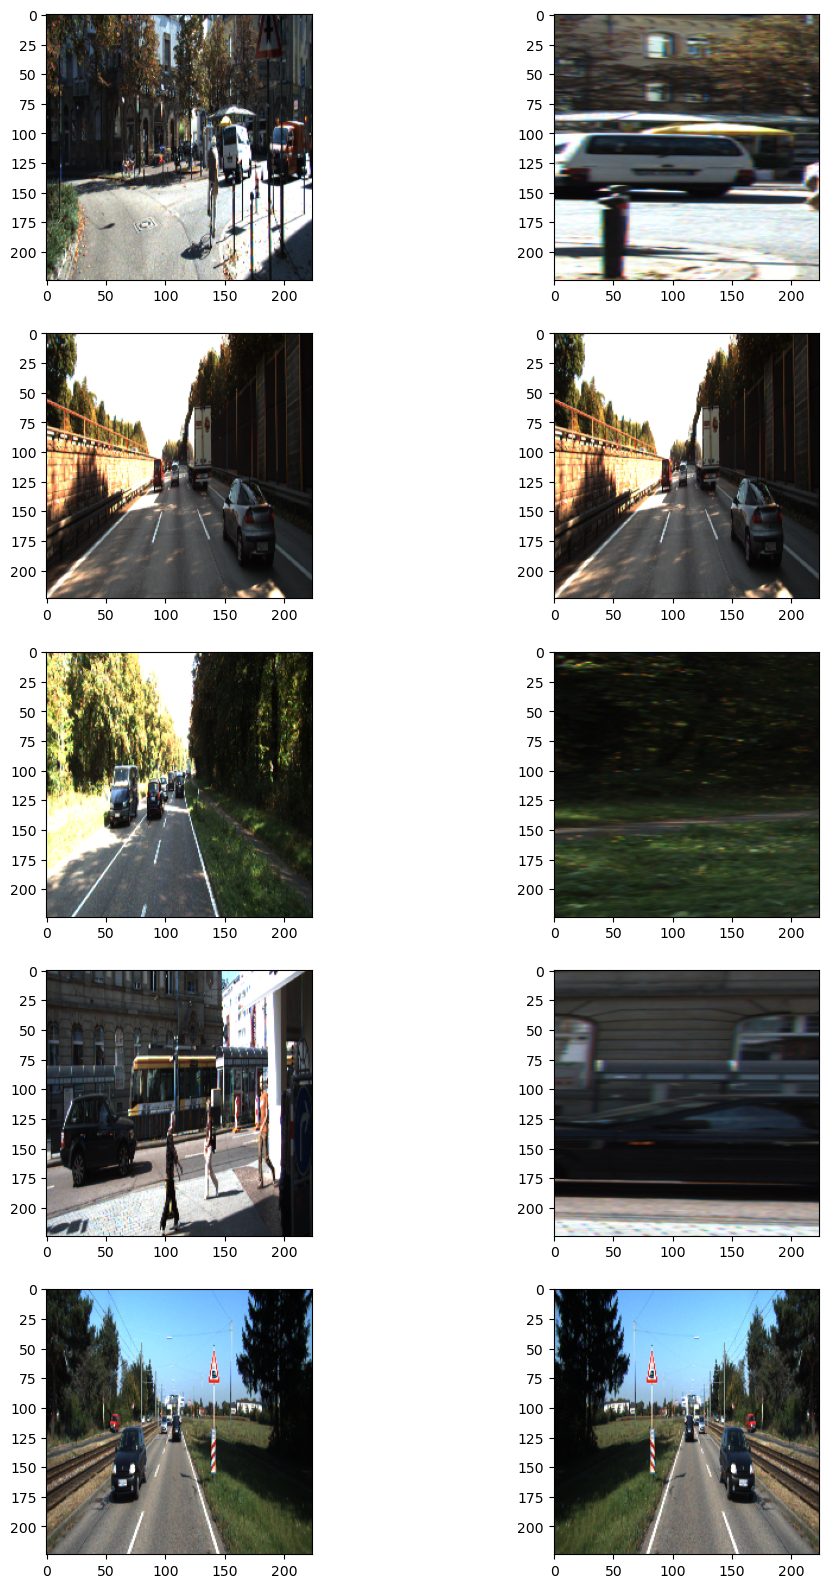

In [6]:
augmentation_train = build_augmentation()
augmentation_test = build_augmentation(is_train=False)
input_images = glob(os.path.join(TRAIN_DATA_DIR, "image_2", "*.png"))

# 훈련 데이터셋에서 5개만 가져와 augmentation을 적용해 보기
plt.figure(figsize=(12, 20))
for i in range(5):
    image = imread(input_images[i])
    image_data = {"image":image}
    resized = augmentation_test(**image_data)
    processed = augmentation_train(**image_data)
    plt.subplot(5, 2, 2*i+1)
    plt.imshow(resized["image"])  # 왼쪽이 원본 이미지
    plt.subplot(5, 2, 2*i+2)
    plt.imshow(processed["image"])  # 오른쪽이 augment된 이미지

plt.show()

### 2-2. KITTI Dataset 클래스 정의

**주요 변경 사항:**  

예제 코드에서는 load_dataset 함수가 `is_train = True` 인자를 받을 경우 training set 에서 마지막 30장을 이용해 학습 후 모델의 성능을 검증했다. 그러나 이제 모델 3개를 **비교**할 예정이므로 training set 에서 validation set 을 8:2 비율로 분리해 보다 신뢰도 높게 성능을 측정한다.

In [7]:
class KittiDataset(Dataset):
    '''
    KittiDataset은 PyTorch의 Dataset을 상속받는다.
    KITTI 데이터를 원하는 방식으로 전처리하기 위해 커스텀 Dataset을 사용한다.

    split 파라미터:
      - 'train' : TRAIN_DATA_DIR 이미지의 앞 80% (라벨 있음, 학습용)
      - 'val'   : TRAIN_DATA_DIR 이미지의 뒤 20% (라벨 있음, 정량 평가용 / IoU 비교)
      - 'test'  : TEST_DATA_DIR 이미지 전체     (라벨 없음, 정성 평가용 / 시각화)
    '''
    def __init__(self,
                 img_size=(224, 224, 3),
                 output_size=(224, 224),
                 split='train',
                 augmentation=None):
        self.split        = split        # 'train' / 'val' / 'test'
        self.augmentation = augmentation
        self.img_size     = img_size
        self.output_size  = output_size
        self.data         = self.load_dataset()

    def load_dataset(self):
        if self.split == 'test':
            # 공식 KITTI test set: 라벨(semantic/) 디렉토리가 없음
            # input_images 만 로드, label 은 None 으로 채움
            input_images = sorted(glob(os.path.join(TEST_DATA_DIR, 'image_2', '*.png')))
            return list(zip(input_images, [None] * len(input_images)))

        # train / val split: 라벨이 있는 KITTI training 이미지 전체 로드
        input_images = sorted(glob(os.path.join(TRAIN_DATA_DIR, 'image_2',  '*.png')))
        label_images = sorted(glob(os.path.join(TRAIN_DATA_DIR, 'semantic', '*.png')))
        assert len(input_images) == len(label_images), "이미지 수와 라벨 수가 다름"

        data = list(zip(input_images, label_images))

        # 8:2 분할 (train 80%, val 20%)
        split_idx = int(len(data) * 0.8)
        if self.split == 'train':
            return data[:split_idx]
        else:   # 'val'
            return data[split_idx:]

    def __len__(self):
        return len(self.data)

    def __getitem__(self, index):
        input_img_path, output_path = self.data[index]

        _input = imread(input_img_path)

        if output_path is None:
            # test set: 라벨 없음 → 더미 마스크 반환
            _output = np.zeros((_input.shape[0], _input.shape[1]), dtype=np.uint8)
        else:
            _output = imread(output_path)
            # 도로(class 7)를 이진 마스크로 변환
            _output = (_output == 7).astype(np.uint8)

        data = {"image": _input, "mask": _output}

        if self.augmentation:
            augmented = self.augmentation(**data)
            _input  = augmented["image"] / 255.0   # 정규화
            _output = augmented["mask"]

        # (H, W) → (1, H, W) 차원 추가
        _output = np.expand_dims(_output, axis=0)

        return (
            torch.tensor(_input,  dtype=torch.float32).permute(2, 0, 1),  # (C, H, W)
            torch.tensor(_output, dtype=torch.float32)                     # (1, H, W)
        )

    def shuffle_data(self):
        if self.split == 'train':
            np.random.shuffle(self.data)

### 2-3. DataLoader 생성

In [8]:
# Augmentation 설정
augmentation_train = build_augmentation(is_train=True)
augmentation_val = build_augmentation(is_train=False)  # val/test 는 augmentation 미적용

# 데이터셋 생성
# train / val : 라벨 있는 KITTI training 이미지를 8:2로 분할
#   train → 학습, val → 정량 평가(IoU 비교, 모델 선택 근거)
# test  : 라벨 없는 공식 KITTI test 이미지 → 정성 평가(시각화 결과 제출)
train_dataset = KittiDataset(split='train', augmentation=augmentation_train)
val_dataset = KittiDataset(split='val',   augmentation=augmentation_val)
test_dataset = KittiDataset(split='test',  augmentation=augmentation_val)

In [9]:
# U-Net++ 는 U-Net 대비 메모리를 더 많이 사용하므로 배치 사이즈를 적당히 작게 설정
BATCH_SIZE = 8

# DataLoader 내부 worker의 난수도 고정
# worker_init_fn : 각 worker 프로세스 시작 시 난수 시드를 고정
# generator      : 배치 셔플 순서를 결정하는 난수 생성기를 고정
def seed_worker(worker_id):
    worker_seed = SEED + worker_id
    np.random.seed(worker_seed)
    random.seed(worker_seed)

g = torch.Generator()
g.manual_seed(SEED)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          worker_init_fn=seed_worker, generator=g)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          worker_init_fn=seed_worker, generator=g)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,
                          worker_init_fn=seed_worker, generator=g)

print(f"train 샘플 수 : {len(train_dataset)}")
print(f"val   샘플 수 : {len(val_dataset)}")
print(f"test  샘플 수 : {len(test_dataset)}  (라벨 없음 → 정성 평가에 사용)")

train 샘플 수 : 160
val   샘플 수 : 40
test  샘플 수 : 200  (라벨 없음 → 정성 평가에 사용)


## 3. 모델 구현

3가지 모델 모두 Bottleneck 직후 딱 한 번만 Dropout을 적용한다. 이유는 Bottleneck이 가장 압축된 표현(가장 추상적인 feature)을 담고 있어서, 여기서 일부 정보를 무작위로 차단하면 모델이 특정 패턴에 과하게 의존하는 걸 가장 효과적으로 막을 수 있기 때문이다.  

반면 인코더나 디코더 중간 레이어에 Dropout을 넣으면 공간적 특징이 과하게 손상되어 세그멘테이션 품질이 오히려 떨어질 수 있어 권장하지 않는다.

### 3-1. U-Net

In [10]:
class UNet(nn.Module):
    '''
    기존 U-Net 구현체 (Encoder-Decoder + Skip Connection)
    - 4단계 Encoder / 4단계 Decoder 구조
    - 각 단계는 double_conv (3×3 Conv + BN + ReLU) × 2로 구성
    '''
    def __init__(self, input_channels=3, output_channels=1):
        super(UNet, self).__init__()

        # Encoder (Contracting Path)
        self.enc1  = self.double_conv(input_channels, 64)
        self.pool1 = nn.MaxPool2d(2)
        self.enc2  = self.double_conv(64, 128)
        self.pool2 = nn.MaxPool2d(2)
        self.enc3  = self.double_conv(128, 256)
        self.pool3 = nn.MaxPool2d(2)
        self.enc4  = self.double_conv(256, 512)
        self.pool4 = nn.MaxPool2d(2)

        # Bottleneck
        self.bottleneck = self.double_conv(512, 1024)
        self.dropout    = nn.Dropout(0.5) # 학습 중 뉴런을 50% 확률(`p=0.5`)로 무작위로 가지치기

        # Decoder (Expanding Path)
        self.up6  = nn.ConvTranspose2d(1024, 512, kernel_size=2, stride=2)
        self.dec6 = self.double_conv(1024, 512)
        self.up7  = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.dec7 = self.double_conv(512, 256)
        self.up8  = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.dec8 = self.double_conv(256, 128)
        self.up9  = nn.ConvTranspose2d(128, 64,  kernel_size=2, stride=2)
        self.dec9 = self.double_conv(128, 64)

        # Output Layer
        self.final = nn.Conv2d(64, output_channels, kernel_size=1)

    def double_conv(self, in_channels, out_channels):
        # 3×3 Conv → BN → ReLU → 3×3 Conv → BN → ReLU 블록 (2개의 conv 레이어로 이루어짐)
        return nn.Sequential(
            nn.Conv2d(in_channels,  out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        # Encoder
        c1 = self.enc1(x);   p1 = self.pool1(c1)
        c2 = self.enc2(p1);  p2 = self.pool2(c2)
        c3 = self.enc3(p2);  p3 = self.pool3(c3)
        c4 = self.enc4(p3);  p4 = self.pool4(c4)

        # Bottleneck
        c5 = self.dropout(self.bottleneck(p4))

        # Decoder: Upsample → Concat 이전 레벨 skip feature → double_conv
        u6 = self.up6(c5);  c6 = self.dec6(torch.cat([u6, c4], dim=1))
        u7 = self.up7(c6);  c7 = self.dec7(torch.cat([u7, c3], dim=1))
        u8 = self.up8(c7);  c8 = self.dec8(torch.cat([u8, c2], dim=1))
        u9 = self.up9(c8);  c9 = self.dec9(torch.cat([u9, c1], dim=1))

        return torch.sigmoid(self.final(c9))

### 3-2. U-Net++ v1

In [11]:
class UNetPlusPlus(nn.Module):
    '''
    U-Net++ v1
    - 5 레벨(i=0..4) × 최대 5 열(j=0..4) 의 격자(Dense Skip Connection) 구조
    - Deep Supervision: x^{0,1} ~ x^{0,4} 4개 예측을 평균하여 최종 출력
    '''
    def __init__(self, input_channels=3, output_channels=1, filters=None):
        super(UNetPlusPlus, self).__init__()

        # 각 레벨별 채널 수 (U-Net과 동일하게 설정)
        if filters is None:
            filters = [64, 128, 256, 512, 1024]

        self.filters         = filters
        self.output_channels = output_channels

        # MaxPool: x^{i,0} → x^{i+1,0} 다운샘플
        self.pool = nn.ModuleList([nn.MaxPool2d(2) for _ in range(4)])

        # 백본 인코더 노드 x^{i,0} (j=0 열)
        self.x_0_0 = self.double_conv(input_channels, filters[0])
        self.x_1_0 = self.double_conv(filters[0],     filters[1])
        self.x_2_0 = self.double_conv(filters[1],     filters[2])
        self.x_3_0 = self.double_conv(filters[2],     filters[3])
        self.x_4_0 = self.double_conv(filters[3],     filters[4])  # bottleneck

        # 업샘플 레이어: up[i_j] = x^{i+1,j} → x^{i, j+1} 계산에 사용
        self.up = nn.ModuleDict()
        for i in range(4):
            for j in range(4 - i):
                self.up[f"{i}_{j}"] = nn.ConvTranspose2d(
                    filters[i + 1], filters[i], kernel_size=2, stride=2
                )

        # 밀집 노드 x^{i,j} (j>0) 합성 Conv
        # 입력 채널 = filters[i] × (j + 1)  (이전 j개 + 업샘플 1개)
        self.conv = nn.ModuleDict()
        for i in range(4):
            for j in range(1, 5 - i):
                in_ch = filters[i] * (j + 1)
                self.conv[f"{i}_{j}"] = self.double_conv(in_ch, filters[i])

        # Deep Supervision 출력 헤드: x^{0,1} ~ x^{0,4} 각각에 1×1 Conv
        self.outputs = nn.ModuleList([
            nn.Conv2d(filters[0], output_channels, kernel_size=1) for _ in range(4)
        ])

        self.dropout = nn.Dropout(0.5)

    def double_conv(self, in_channels, out_channels):
        # H(·): 3×3 Conv → BN → ReLU → 3×3 Conv → BN → ReLU 블록
        return nn.Sequential(
            nn.Conv2d(in_channels,  out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        nodes = {}  # nodes[(i, j)] = feature tensor

        # Step 1. 백본 인코더: x^{i,0} 계산
        nodes[(0, 0)] = self.x_0_0(x)
        nodes[(1, 0)] = self.x_1_0(self.pool[0](nodes[(0, 0)]))
        nodes[(2, 0)] = self.x_2_0(self.pool[1](nodes[(1, 0)]))
        nodes[(3, 0)] = self.x_3_0(self.pool[2](nodes[(2, 0)]))
        nodes[(4, 0)] = self.dropout(
            self.x_4_0(self.pool[3](nodes[(3, 0)]))   # bottleneck
        )

        # Step 2. 밀집 스킵 연결 노드 계산 (대각선 방향: j=1 → j=4)
        # x^{i,j} = H( [x^{i,0}, ..., x^{i,j-1}, U(x^{i+1,j-1})] )
        for j in range(1, 5):            # 열(column) j
            for i in range(4 - j + 1):   # 행(row) i (삼각형 격자)
                # 아래 레벨 i+1, 이전 열 j-1 의 feature를 업샘플
                upsampled = self.up[f"{i}_{j-1}"](nodes[(i + 1, j - 1)])
                # 같은 레벨 i 의 이전 열 feature 모두 수집
                prev_same_level = [nodes[(i, k)] for k in range(j)]
                # concat 후 H(·) 적용
                concatenated    = torch.cat(prev_same_level + [upsampled], dim=1)
                nodes[(i, j)]   = self.conv[f"{i}_{j}"](concatenated)

        # Step 3. Deep Supervision: x^{0,1}~x^{0,4} 출력 헤드 적용 후 평균
        seg_outputs = [
            torch.sigmoid(self.outputs[j - 1](nodes[(0, j)]))
            for j in range(1, 5)
        ]
        return torch.mean(torch.stack(seg_outputs, dim=0), dim=0)

### 3-3. U-Net++ v2 (추가 실험)

In [12]:
class UNetPlusPlusV2(nn.Module):
    '''
    U-Net++ v2
    v1 대비 개선점:
      1) 업샘플 직후 1×1 Conv 채널 정렬 추가 (re-designed decoder)
      2) deep_supervision 인자로 학습/추론 모드 분리
      3) 학습 시 4개 segmentation output 반환 → 외부 deep supervision loss 계산
    '''
    def __init__(self, input_channels=3, output_channels=1,
                 filters=None, deep_supervision=True):
        super(UNetPlusPlusV2, self).__init__()

        if filters is None:
            filters = [64, 128, 256, 512, 1024]

        self.filters          = filters
        self.output_channels  = output_channels
        self.deep_supervision = deep_supervision  # True: 다중 출력(학습), False: 단일 출력(추론)

        # MaxPool (다운샘플링)
        self.pool = nn.ModuleList([nn.MaxPool2d(2) for _ in range(4)])

        # 백본 인코더 노드 x^{i,0}
        self.x_0_0 = self.double_conv(input_channels, filters[0])
        self.x_1_0 = self.double_conv(filters[0],     filters[1])
        self.x_2_0 = self.double_conv(filters[1],     filters[2])
        self.x_3_0 = self.double_conv(filters[2],     filters[3])
        self.x_4_0 = self.double_conv(filters[3],     filters[4])

        # 업샘플 레이어 (TransposeConv)
        self.up = nn.ModuleDict()
        for i in range(4):
            for j in range(4 - i):
                self.up[f"{i}_{j}"] = nn.ConvTranspose2d(
                    filters[i + 1], filters[i], kernel_size=2, stride=2
                )

        # 업샘플 직후 채널 정렬용 1×1 Conv
        # 업샘플 채널 filters[i]를 정렬하여 일관성 확보
        self.up_conv1x1 = nn.ModuleDict()
        for i in range(4):
            for j in range(1, 5 - i):
                self.up_conv1x1[f"{i}_{j}"] = nn.Conv2d(
                    filters[i], filters[i], kernel_size=1
                )

        # 밀집 노드 x^{i,j} (j>0) 합성 Conv
        self.conv = nn.ModuleDict()
        for i in range(4):
            for j in range(1, 5 - i):
                in_ch = filters[i] * (j + 1)
                self.conv[f"{i}_{j}"] = self.double_conv(in_ch, filters[i])

        # Deep Supervision 출력 헤드
        self.outputs = nn.ModuleList([
            nn.Conv2d(filters[0], output_channels, kernel_size=1) for _ in range(4)
        ])

        self.dropout = nn.Dropout(0.5)

    def double_conv(self, in_channels, out_channels):
        # H(·): 3×3 Conv → BN → ReLU → 3×3 Conv → BN → ReLU
        return nn.Sequential(
            nn.Conv2d(in_channels,  out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        nodes = {}

        # Step 1. 백본 인코더
        nodes[(0, 0)] = self.x_0_0(x)
        nodes[(1, 0)] = self.x_1_0(self.pool[0](nodes[(0, 0)]))
        nodes[(2, 0)] = self.x_2_0(self.pool[1](nodes[(1, 0)]))
        nodes[(3, 0)] = self.x_3_0(self.pool[2](nodes[(2, 0)]))
        nodes[(4, 0)] = self.dropout(self.x_4_0(self.pool[3](nodes[(3, 0)])))

        # Step 2. 밀집 스킵 연결 노드 계산
        for j in range(1, 5):
            for i in range(4 - j + 1):
                # [v2] 업샘플 후 1×1 Conv로 채널 정렬
                upsampled = self.up[f"{i}_{j-1}"](nodes[(i + 1, j - 1)])
                upsampled = self.up_conv1x1[f"{i}_{j}"](upsampled)

                prev_same_level = [nodes[(i, k)] for k in range(j)]
                concatenated    = torch.cat(prev_same_level + [upsampled], dim=1)
                nodes[(i, j)]   = self.conv[f"{i}_{j}"](concatenated)

        # Step 3. 출력
        seg_outputs = [
            torch.sigmoid(self.outputs[j - 1](nodes[(0, j)]))
            for j in range(1, 5)
        ]

        if self.deep_supervision:
            # 학습 시: 4개 출력 모두 반환 → 외부에서 각각 손실 계산
            return seg_outputs
        else:
            # 추론 시: 가장 정제된 마지막 열 x^{0,4}만 반환
            return seg_outputs[-1]

## 4. 모델 학습

### 4-1. 손실 함수 정의

다음과 같은 사용자 정의 손실 함수를 이용한다.  

$L = 0.5 × Weighted BCE + Dice Loss$  

- Weighted BCE: 학습 데이터에서 직접 계산한 pos_weight를 적용해 도로 픽셀(소수 클래스)을 틀렸을 때 페널티를 더 크게 부여

- Dice Loss: 픽셀 수보다 겹치는 영역 비율에 집중, 클래스 불균형에 자연스럽게 강인

In [13]:
# 클래스 가중치 계산 (픽셀 불균형 보정)
# train set 라벨 전체를 순회하여 도로(class 7) 픽셀 비율을 직접 계산
# pos_weight = 비도로 픽셀 수 / 도로 픽셀 수
# 도로 픽셀을 틀렸을 때 페널티를 비도로보다 pos_weight 배 크게 부여
print("pos_weight 계산 중 (train set 전체 라벨 순회)...")
total_pixels = 0
road_pixels  = 0
for _, label_path in train_dataset.data:
    label        = imread(label_path)
    road_pixels  += int((label == 7).sum())
    total_pixels += int(label.size)

pos_weight_value = (total_pixels - road_pixels) / (road_pixels + 1e-7)
POS_WEIGHT       = torch.tensor([pos_weight_value]).to(device)
print(f"전체 픽셀 : {total_pixels:,}")
print(f"도로 픽셀 : {road_pixels:,}  ({100 * road_pixels / total_pixels:.1f}%)")
print(f"비도로 픽셀: {total_pixels - road_pixels:,}  ({100 * (1 - road_pixels/total_pixels):.1f}%)")
print(f"pos_weight : {pos_weight_value:.4f}")

pos_weight 계산 중 (train set 전체 라벨 순회)...
전체 픽셀 : 74,486,046
도로 픽셀 : 17,358,951  (23.3%)
비도로 픽셀: 57,127,095  (76.7%)
pos_weight : 3.2909


In [14]:
def dice_coefficient(pred, target, smooth=1.0):
    '''
    Dice Coefficient: 2 * |X ∩ Y| / (|X| + |Y|)
    - pred, target: (N, 1, H, W) sigmoid 출력
    - smooth: 분모 0 방지용 smoothing 상수
    '''
    pred_flat    = pred.view(-1)
    target_flat  = target.view(-1)
    intersection = (pred_flat * target_flat).sum()
    return (2.0 * intersection + smooth) / (pred_flat.sum() + target_flat.sum() + smooth)

In [15]:
def bce_dice_loss(pred, target):
    '''
    Weighted BCE + Dice 혼합 손실 (픽셀 불균형 보정)

    L = 0.5 * Weighted BCE + Dice Loss

    - Weighted BCE : 도로 픽셀(소수 클래스)에 pos_weight 배로 페널티 부여
                     -> 모델이 도로를 비도로로 틀렸을 때 더 크게 학습
                     -> F.binary_cross_entropy 대신 logits 버전 사용
                        (sigmoid를 내부에서 처리하여 수치 안정성 확보)
    - Dice         : 픽셀 수보다 겹치는 영역 비율에 집중
                     -> 소수 클래스(도로)에 자연스럽게 더 민감하게 반응
    '''
    # pred는 이미 sigmoid를 통과한 값 → logit으로 역변환 후 weighted BCE 계산
    # clamp로 log(0) 방지
    pred_logit = torch.log(pred.clamp(min=1e-7) / (1 - pred).clamp(min=1e-7))
    bce  = F.binary_cross_entropy_with_logits(pred_logit, target, pos_weight=POS_WEIGHT)
    dice = 1.0 - dice_coefficient(pred, target)
    return 0.5 * bce + dice

In [16]:
def deep_supervision_loss(preds_list, target):
    '''
    U-Net++ v2 Deep Supervision 손실
    - preds_list: [x^{0,1}, x^{0,2}, x^{0,3}, x^{0,4}] 4개의 예측
    - 각 예측에 bce_dice_loss 계산 후 평균 반환
    '''
    return torch.mean(torch.stack([bce_dice_loss(p, target) for p in preds_list]))

### 4-2. 학습/평가 유틸리티 함수 정의

In [17]:
def compute_accuracy(pred, target, threshold=0.5):
    '''픽셀 단위 이진 정확도 계산 (sigmoid 출력 기준)'''
    if isinstance(pred, list):   # deep supervision 출력 처리
        pred = pred[-1]
    pred_bin = (pred > threshold).float()
    correct  = (pred_bin == target).float().sum()
    return (correct / target.numel()).item()

**Accuracy**는 **전체 픽셀 중 예측값과 GT가 일치한 픽셀의 비율**이다. Loss 하나만으로는 모델이 실제로 무엇을 배우고 있는지 쉽게 이해하기 어렵다고 생각해 학습 진행 시 두 값을 함께 비교하기 위해 추가했다.  

예를 들어 Loss가 정체된 상황에서 Accuracy만 계속 향상된다면 이미지 내에서 비교적 쉬운 픽셀 (하늘 등 배경) 만 맞추고 있을 가능성이 높다고 볼 수 있다.

In [18]:
def train_one_epoch(model, loader, optimizer, loss_fn, is_deep_sup=False):
    '''
    1 epoch 학습
    - is_deep_sup=True  : deep_supervision_loss 사용 (UNet++ v2)
    - is_deep_sup=False : bce_dice_loss 사용 (UNet, UNet++ v1)
    '''
    model.train()
    total_loss, total_acc = 0.0, 0.0

    for inputs, targets in loader:
        inputs, targets = inputs.to(device), targets.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)

        loss = deep_supervision_loss(outputs, targets) if is_deep_sup \
               else loss_fn(outputs, targets)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_acc  += compute_accuracy(outputs, targets)

    n = len(loader)
    return total_loss / n, total_acc / n

In [19]:
def evaluate(model, loader, loss_fn, is_deep_sup=False):
    '''검증 루프 (gradient 없음)'''
    model.eval()
    total_loss, total_acc = 0.0, 0.0

    with torch.no_grad():
        for inputs, targets in loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)

            loss = deep_supervision_loss(outputs, targets) if is_deep_sup \
                   else loss_fn(outputs, targets)

            total_loss += loss.item()
            total_acc  += compute_accuracy(outputs, targets)

    n = len(loader)
    return total_loss / n, total_acc / n

###  4-3. 학습

In [20]:
# 하이퍼파라미터 설정
NUM_EPOCHS = 100
LR         = 1e-4

# 세 모델의 학습 기록을 하나의 딕셔너리로 통합 관리
history = {
    'unet':    {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []},
    'unet_pp': {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []},
    'unet_v2': {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []},
}

In [21]:
%%time

# 기본 U-Net 학습
torch.manual_seed(SEED) # 시드 고정

unet_model = UNet(input_channels=3, output_channels=1).to(device)
unet_optim = optim.Adam(unet_model.parameters(), lr=LR)

print("=" * 50)
print("U-Net 학습 시작")
print("=" * 50)

for epoch in range(1, NUM_EPOCHS + 1):
    tr_loss, tr_acc = train_one_epoch(unet_model, train_loader, unet_optim, bce_dice_loss)
    va_loss, va_acc = evaluate(unet_model, val_loader, bce_dice_loss)

    history['unet']['train_loss'].append(tr_loss)
    history['unet']['val_loss'].append(va_loss)
    history['unet']['train_acc'].append(tr_acc)
    history['unet']['val_acc'].append(va_acc)

    if epoch % 10 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d}/{NUM_EPOCHS} | "
              f"Train Loss: {tr_loss:.4f}, Acc: {tr_acc:.4f} | "
              f"Val Loss: {va_loss:.4f}, Acc: {va_acc:.4f}")

torch.save(unet_model.state_dict(), os.path.join(SAVE_DIR, 'seg_model_unet.pth'))
print("U-Net 모델 저장 완료")

U-Net 학습 시작
Epoch   1/100 | Train Loss: 0.8747, Acc: 0.8354 | Val Loss: 1.1911, Acc: 0.2213
Epoch  10/100 | Train Loss: 0.4413, Acc: 0.9333 | Val Loss: 0.5785, Acc: 0.9061
Epoch  20/100 | Train Loss: 0.3739, Acc: 0.9420 | Val Loss: 0.5065, Acc: 0.9202
Epoch  30/100 | Train Loss: 0.3246, Acc: 0.9462 | Val Loss: 0.5301, Acc: 0.9212
Epoch  40/100 | Train Loss: 0.3006, Acc: 0.9481 | Val Loss: 0.4108, Acc: 0.9267
Epoch  50/100 | Train Loss: 0.3124, Acc: 0.9347 | Val Loss: 0.4215, Acc: 0.9166
Epoch  60/100 | Train Loss: 0.2758, Acc: 0.9483 | Val Loss: 0.4291, Acc: 0.9271
Epoch  70/100 | Train Loss: 0.2467, Acc: 0.9537 | Val Loss: 0.3374, Acc: 0.9402
Epoch  80/100 | Train Loss: 0.2375, Acc: 0.9530 | Val Loss: 0.3413, Acc: 0.9367
Epoch  90/100 | Train Loss: 0.2305, Acc: 0.9566 | Val Loss: 0.4319, Acc: 0.9363
Epoch 100/100 | Train Loss: 0.2670, Acc: 0.9447 | Val Loss: 0.3391, Acc: 0.9408
U-Net 모델 저장 완료
CPU times: user 24min 2s, sys: 11.1 s, total: 24min 13s
Wall time: 19min 24s


In [22]:
%%time

# U-Net++ v1 학습
torch.manual_seed(SEED) # 시드 고정

unetpp_model = UNetPlusPlus(input_channels=3, output_channels=1).to(device)
unetpp_optim = optim.Adam(unetpp_model.parameters(), lr=LR)

print("=" * 50)
print("U-Net++ v1 학습 시작")
print("=" * 50)

for epoch in range(1, NUM_EPOCHS + 1):
    tr_loss, tr_acc = train_one_epoch(unetpp_model, train_loader, unetpp_optim, bce_dice_loss)
    va_loss, va_acc = evaluate(unetpp_model, val_loader, bce_dice_loss)

    history['unet_pp']['train_loss'].append(tr_loss)
    history['unet_pp']['val_loss'].append(va_loss)
    history['unet_pp']['train_acc'].append(tr_acc)
    history['unet_pp']['val_acc'].append(va_acc)

    if epoch % 10 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d}/{NUM_EPOCHS} | "
              f"Train Loss: {tr_loss:.4f}, Acc: {tr_acc:.4f} | "
              f"Val Loss: {va_loss:.4f}, Acc: {va_acc:.4f}")

torch.save(unetpp_model.state_dict(), os.path.join(SAVE_DIR, 'seg_model_unetpp_v1.pth'))
print("U-Net++ v1 모델 저장 완료")

U-Net++ v1 학습 시작
Epoch   1/100 | Train Loss: 0.9044, Acc: 0.8239 | Val Loss: 1.2035, Acc: 0.2213
Epoch  10/100 | Train Loss: 0.4991, Acc: 0.9195 | Val Loss: 0.5761, Acc: 0.9112
Epoch  20/100 | Train Loss: 0.4657, Acc: 0.9196 | Val Loss: 0.6119, Acc: 0.8947
Epoch  30/100 | Train Loss: 0.3380, Acc: 0.9494 | Val Loss: 0.4473, Acc: 0.9181
Epoch  40/100 | Train Loss: 0.3205, Acc: 0.9488 | Val Loss: 0.4807, Acc: 0.9241
Epoch  50/100 | Train Loss: 0.2834, Acc: 0.9485 | Val Loss: 0.4834, Acc: 0.9225
Epoch  60/100 | Train Loss: 0.2749, Acc: 0.9487 | Val Loss: 0.4656, Acc: 0.9242
Epoch  70/100 | Train Loss: 0.2676, Acc: 0.9506 | Val Loss: 0.4050, Acc: 0.9326
Epoch  80/100 | Train Loss: 0.2439, Acc: 0.9520 | Val Loss: 0.3421, Acc: 0.9372
Epoch  90/100 | Train Loss: 0.2141, Acc: 0.9576 | Val Loss: 0.4164, Acc: 0.9307
Epoch 100/100 | Train Loss: 0.2244, Acc: 0.9622 | Val Loss: 0.4875, Acc: 0.9307
U-Net++ v1 모델 저장 완료
CPU times: user 46min 47s, sys: 12.9 s, total: 47min
Wall time: 42min 11s


In [23]:
%%time

# U-Net++ v2 학습
torch.manual_seed(SEED) # 시드 고정

unetv2_model = UNetPlusPlusV2(input_channels=3, output_channels=1,
                               deep_supervision=True).to(device)
unetv2_optim = optim.Adam(unetv2_model.parameters(), lr=LR)

print("=" * 50)
print("U-Net++ v2 학습 시작")
print("=" * 50)

for epoch in range(1, NUM_EPOCHS + 1):
    # v2는 deep supervision loss 사용
    tr_loss, tr_acc = train_one_epoch(unetv2_model, train_loader, unetv2_optim,
                                       bce_dice_loss, is_deep_sup=True)
    va_loss, va_acc = evaluate(unetv2_model, val_loader, bce_dice_loss, is_deep_sup=True)

    history['unet_v2']['train_loss'].append(tr_loss)
    history['unet_v2']['val_loss'].append(va_loss)
    history['unet_v2']['train_acc'].append(tr_acc)
    history['unet_v2']['val_acc'].append(va_acc)

    if epoch % 10 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d}/{NUM_EPOCHS} | "
              f"Train Loss: {tr_loss:.4f}, Acc: {tr_acc:.4f} | "
              f"Val Loss: {va_loss:.4f}, Acc: {va_acc:.4f}")

# 추론 시에는 deep_supervision=False 로 전환
unetv2_model.deep_supervision = False
torch.save(unetv2_model.state_dict(), os.path.join(SAVE_DIR, 'seg_model_unetpp_v2.pth'))
print("U-Net++ v2 모델 저장 완료")

U-Net++ v2 학습 시작
Epoch   1/100 | Train Loss: 0.9247, Acc: 0.7281 | Val Loss: 1.2720, Acc: 0.2213
Epoch  10/100 | Train Loss: 0.5123, Acc: 0.9311 | Val Loss: 0.6582, Acc: 0.9080
Epoch  20/100 | Train Loss: 0.4432, Acc: 0.9385 | Val Loss: 0.5647, Acc: 0.9150
Epoch  30/100 | Train Loss: 0.3687, Acc: 0.9444 | Val Loss: 0.5730, Acc: 0.9109
Epoch  40/100 | Train Loss: 0.3281, Acc: 0.9456 | Val Loss: 0.4672, Acc: 0.9306
Epoch  50/100 | Train Loss: 0.3580, Acc: 0.9446 | Val Loss: 0.5838, Acc: 0.9270
Epoch  60/100 | Train Loss: 0.3252, Acc: 0.9447 | Val Loss: 0.4329, Acc: 0.9339
Epoch  70/100 | Train Loss: 0.2746, Acc: 0.9597 | Val Loss: 0.4718, Acc: 0.9366
Epoch  80/100 | Train Loss: 0.2773, Acc: 0.9586 | Val Loss: 0.5208, Acc: 0.9260
Epoch  90/100 | Train Loss: 0.2537, Acc: 0.9638 | Val Loss: 0.5021, Acc: 0.9332
Epoch 100/100 | Train Loss: 0.2276, Acc: 0.9666 | Val Loss: 0.4045, Acc: 0.9456
U-Net++ v2 모델 저장 완료
CPU times: user 49min 8s, sys: 13.4 s, total: 49min 22s
Wall time: 44min 32s


### 4-4. 학습 곡선 확인

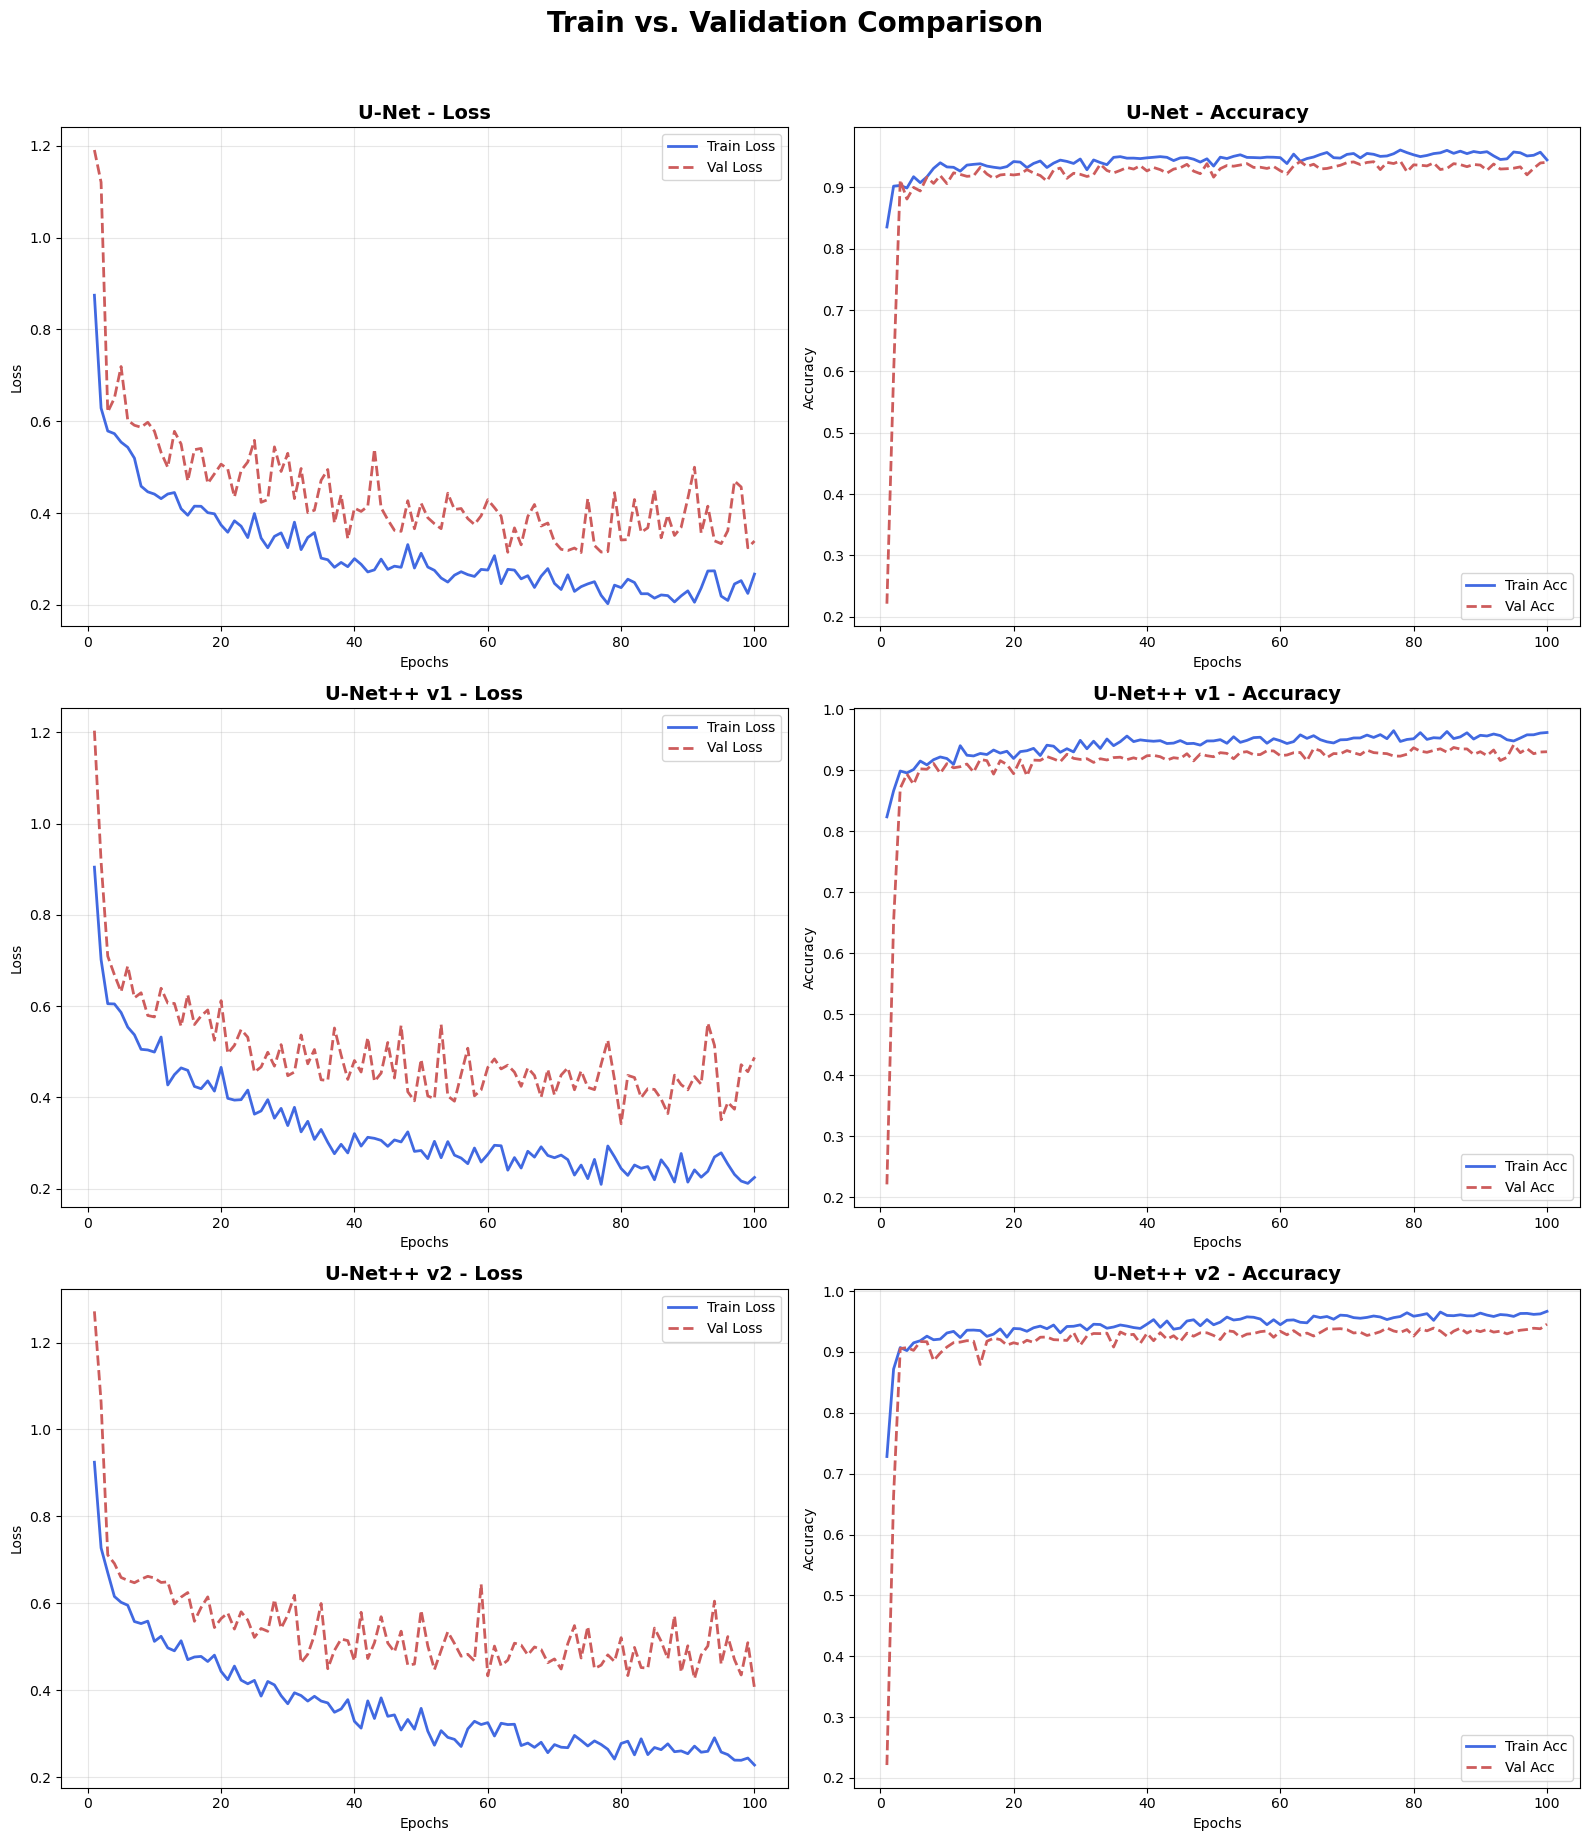

In [24]:
# 모델 리스트와 설정
keys = ['unet', 'unet_pp', 'unet_v2']
model_names = {'unet': 'U-Net', 'unet_pp': 'U-Net++ v1', 'unet_v2': 'U-Net++ v2'}
epochs_range = range(1, NUM_EPOCHS + 1)

# 3행(모델별) 2열(Loss, Acc) 서브플롯 생성
fig, axes = plt.subplots(3, 2, figsize=(16, 18))
fig.suptitle("Train vs. Validation Comparison", fontsize=20, fontweight='bold', y=1.02)

for i, key in enumerate(keys):
    # 좌측 열: Loss (Train vs Val)
    ax_loss = axes[i, 0]
    ax_loss.plot(epochs_range, history[key]['train_loss'], label='Train Loss', color='royalblue', linewidth=2)
    ax_loss.plot(epochs_range, history[key]['val_loss'], label='Val Loss', color='indianred', linestyle='--', linewidth=2)
    ax_loss.set_title(f"{model_names[key]} - Loss", fontsize=14, fontweight='bold')
    ax_loss.set_xlabel('Epochs')
    ax_loss.set_ylabel('Loss')
    ax_loss.legend()
    ax_loss.grid(True, alpha=0.3)

    # 우측 열: Accuracy (Train vs Val)
    ax_acc = axes[i, 1]
    ax_acc.plot(epochs_range, history[key]['train_acc'], label='Train Acc', color='royalblue', linewidth=2)
    ax_acc.plot(epochs_range, history[key]['val_acc'], label='Val Acc', color='indianred', linestyle='--', linewidth=2)
    ax_acc.set_title(f"{model_names[key]} - Accuracy", fontsize=14, fontweight='bold')
    ax_acc.set_xlabel('Epochs')
    ax_acc.set_ylabel('Accuracy')
    ax_acc.legend(loc='lower right')
    ax_acc.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'model_specific_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

- **U-Net:** 초기 수렴 속도가 가장 빠르며 약 20~30 에포크 지점에서 이미 안정적인 성능 궤도에 진입하지만, 80 에포크 이후 Validation Loss가 반등하며 미세한 과적합 징후를 보였다.

- **U-Net++ v1:** 세 모델 중 가장 매끄러운 곡선을 그리면서 약 40~50 에포크 부근에서 수렴하며, 이후 학습 종료 시까지 Train-Validation 간의 격차가 가장 적게 유지되었다.

- **U-Net++ v2:** 가장 높은 정확도에 도달하지만 수렴 과정은 가장 느리고 불안정하여 약 60~70 에포크에 이르러서야 성능이 일정 범위 내로 고착되는 양상이었다.

## 5. 모델 평가

### 5-1. 모델 구조 확인

In [25]:
# 가중치 로드 시 발생할 수 있는 경로 및 장치 에러 방지
# 저장된 가중치 로드
unet_model.load_state_dict(torch.load(os.path.join(SAVE_DIR, 'seg_model_unet.pth'), map_location=device))
unetpp_model.load_state_dict(torch.load(os.path.join(SAVE_DIR, 'seg_model_unetpp_v1.pth'), map_location=device))
unetv2_model.load_state_dict(torch.load(os.path.join(SAVE_DIR, 'seg_model_unetpp_v2.pth'), map_location=device))

# 구조 출력 루프
# 모델들을 리스트에 담아 하나씩 summary를 호출
models_to_check = [
    (unet_model,   'U-Net'),
    (unetpp_model, 'U-Net++ v1'),
    (unetv2_model, 'U-Net++ v2'),
]

for model, name in models_to_check:
    # 모델을 장치(GPU)로 이동 및 평가 모드 전환
    model.to(device)
    model.eval()

    print(f"\n{'='*40}")
    print(f"  [Model Structure] {name}")
    
    # torchinfo.summary 호출
    # device를 명시하고, 입력 데이터의 dtype을 float32로 고정하여 에러를 방지
    try:
        model_stats = summary(
            model, 
            input_size=(1, 3, 224, 224),
            device=device,
            col_names=["input_size", "output_size", "num_params", "trainable"],
            depth=1,
            row_settings=["var_names"], # 코드상 변수명 같이 출력
            verbose=0  # verbose=0으로 설정하여 내부 로그 중복 출력 방지 가능
        )
        print(model_stats) # summary의 결과를 직접 print()로 감싸서 출력을 강제
        print("\n\n")
        
    except Exception as e:
        print(f"{name} 구조 출력 중 오류 발생: {e}")


  [Model Structure] U-Net
Layer (type (var_name))                  Input Shape               Output Shape              Param #                   Trainable
UNet (UNet)                              [1, 3, 224, 224]          [1, 1, 224, 224]          --                        True
├─Sequential (enc1)                      [1, 3, 224, 224]          [1, 64, 224, 224]         38,976                    True
├─MaxPool2d (pool1)                      [1, 64, 224, 224]         [1, 64, 112, 112]         --                        --
├─Sequential (enc2)                      [1, 64, 112, 112]         [1, 128, 112, 112]        221,952                   True
├─MaxPool2d (pool2)                      [1, 128, 112, 112]        [1, 128, 56, 56]          --                        --
├─Sequential (enc3)                      [1, 128, 56, 56]          [1, 256, 56, 56]          886,272                   True
├─MaxPool2d (pool3)                      [1, 256, 56, 56]          [1, 256, 28, 28]          --         

#### **모델 구조 비교**  

저장된 모델 가중치를 불러와서 모델 구조를 다음 3가지 관점에서 비교한다.

**1. 파라미터 수**

- U-Net vs U-Net++ v1: U-Net++로 넘어오면서 약 500만 개 정도의 파라미터가 증가했다. 이는 단순히 Skip Connection만의 영향이라기 보다 중간에 놓인 Nested Convolution Blocks 때문으로 볼 수 있다.

- U-Net++ v1 vs v2: v2에서 약 46만 개 정도 더 늘어났는데, 이는 up_conv1x1 레이어(채널 수 조절용)가 추가되었기 때문임을 알 수 있었다.


**2. 연산량 (Total mult-adds)**  

- U-Net++는 U-Net보다 약 2.5배(41G -> 105G) 더 많은 연산을 수행했다. 파라미터는 16% 더 많은 수준인데 연산량이 폭증한 이유는 U-Net++의 촘촘한 연결 구조 때문인 것으로 보인다.

**3. 메모리 점유율 (Forward/backward pass size)**

- U-Net++ v2(1,144MB)는 U-Net(440MB)보다 약 2.6배 더 많은 GPU 메모리를 요구했다. 배치 사이즈를 키워야 하는 상황이라면 U-Net이 더 유리하다.

### 5-2. 정량적 평가

IoU 하나만으로는 모델이 **어떤 방향으로 틀렸는지** 알 수 없다.  

자율주행 도로 세그멘테이션에서 오류의 방향은 다음과 같이 다른 결과를 초래한다.
- False Positive (비도로인데 도로 판정): 인도·잔디밭 침범 -> 사고 위험
- False Negative (도로인데 비도로 판정): 주행 가능 영역 손실 -> 경로 이탈

따라서 기본 IoU 외에 Precision / Recall / F1 / 경계 IoU를 함께 측정한다.

In [26]:
def compute_metrics(target, prediction):
    '''
    단일 이미지에 대해 세그멘테이션 지표를 한 번에 계산
    - target, prediction : 이진 numpy 배열 (H, W), 값은 0 또는 1

    반환값 딕셔너리:
      iou       : Intersection over Union
                  → 전체 중첩 성능. 가장 기본 지표
      precision : TP / (TP + FP)
                  → 낮으면 비도로를 도로로 잘못 잡는 경우가 많음 (FP 과다, 안전 위협)
      recall    : TP / (TP + FN)
                  → 낮으면 실제 도로를 못 잡는 경우가 많음 (FN 과다, 주행 영역 손실)
      f1        : 2 * precision * recall / (precision + recall)
                  → precision-recall 균형 지표 (Dice와 동일)
      boundary_iou : 도로 경계 픽셀(팽창 - 침식 3px 이내)만 추출하여 계산한 IoU
                     → 넓은 도로 내부보다 가장자리를 얼마나 정밀하게 잡는지 측정
    '''
    if target.shape != prediction.shape:
        prediction = resize(prediction, target.shape,
                            mode='constant', preserve_range=True).astype(np.uint8)

    tp = float(np.logical_and(prediction == 1, target == 1).sum())
    fp = float(np.logical_and(prediction == 1, target == 0).sum())
    fn = float(np.logical_and(prediction == 0, target == 1).sum())

    eps = 1e-7
    iou       = tp / (tp + fp + fn + eps)
    precision = tp / (tp + fp + eps)
    recall    = tp / (tp + fn + eps)
    f1        = 2 * precision * recall / (precision + recall + eps)

    # 경계 IoU: 팽창(dilate) - 원본 으로 경계 픽셀 추출 후 IoU 계산
    # scipy 없이 numpy stride trick으로 간단히 구현 (3×3 이웃 중 다른 값이 있으면 경계)
    def get_boundary(mask, width=3):
        # 패딩 후 슬라이딩으로 주변 픽셀과 비교 → 경계 픽셀 추출
        pad  = width // 2
        padded = np.pad(mask, pad, mode='constant', constant_values=0)
        boundary = np.zeros_like(mask, dtype=bool)
        for dy in range(width):
            for dx in range(width):
                shifted = padded[dy:dy + mask.shape[0], dx:dx + mask.shape[1]]
                boundary |= (shifted != mask)
        return boundary

    b_pred   = get_boundary(prediction)
    b_target = get_boundary(target)

    b_tp = float(np.logical_and(b_pred, b_target).sum())
    b_fp = float(np.logical_and(b_pred, ~b_target).sum())
    b_fn = float(np.logical_and(~b_pred, b_target).sum())
    boundary_iou = b_tp / (b_tp + b_fp + b_fn + eps)

    return {
        'iou':          iou,
        'precision':    precision,
        'recall':       recall,
        'f1':           f1,
        'boundary_iou': boundary_iou,
    }

In [29]:
def evaluate_metrics_on_dataset(model, dataset, preproc, model_name=""):
    '''
    val set 전체에 대해 5가지 지표의 평균을 계산하여 반환
    - 정량 평가 전용 함수 (val set 에만 사용, 라벨 필요)
    '''
    model.eval()
    # 모델이 현재 어느 장치(CPU 혹은 GPU)에 있는지 자동으로 파악
    device = next(model.parameters()).device
    
    all_metrics = {k: [] for k in ['iou', 'precision', 'recall', 'f1', 'boundary_iou']}

    for img_path, label_path in dataset.data:
        if label_path is None:
            continue

        # 1. 이미지 로드 및 전처리
        origin_img = imread(img_path)
        input_tensor = torch.tensor(
            preproc(image=origin_img)["image"] / 255.0, dtype=torch.float32
        ).permute(2, 0, 1).unsqueeze(0)
        
        # 2. 입력을 모델과 동일한 장치(GPU 등)로 이동 (에러 해결 핵심)
        input_tensor = input_tensor.to(device)

        with torch.no_grad():
            output = model(input_tensor)
            
        # 3. v2의 Deep Supervision(리스트 출력) 대응 및 CPU 이동
        if isinstance(output, list):
            output = output[-1]  # 가장 정교한 마지막 출력 선택
            
        # 4. 넘파이 계산을 위해 CPU로 이동 후 0.5 기준으로 이진화
        # .cpu()를 호출해야 넘파이 변환 시 에러가 나지 않습니다.
        prediction = (output.cpu().squeeze().numpy() > 0.5).astype(np.uint8)

        # 5. GT 라벨 로드 및 이진화 (라벨은 CPU 상에서 처리)
        label_img = imread(label_path)
        target = preproc(image=label_img)["image"]
        if target.ndim == 3:
            target = target[:, :, 0]
        # 도로 클래스(7)만 1로 추출
        target = (target == 7).astype(np.uint8)

        # 6. 개별 이미지에 대한 지표 계산
        m = compute_metrics(target, prediction)
        for k in all_metrics:
            all_metrics[k].append(m[k])

    # 각 지표의 평균 계산
    mean_metrics = {k: float(np.mean(v)) for k, v in all_metrics.items()}

    print(f"\n[{model_name}]  ({len(all_metrics['iou'])}장)")
    print(f"  IoU          : {mean_metrics['iou']:.4f}  ← 전체 중첩 성능")
    print(f"  Precision    : {mean_metrics['precision']:.4f}  ← 낮으면 비도로 침범 많음 (FP↑)")
    print(f"  Recall       : {mean_metrics['recall']:.4f}  ← 낮으면 도로 누락 많음   (FN↑)")
    print(f"  F1 (Dice)    : {mean_metrics['f1']:.4f}  ← Precision·Recall 균형")
    print(f"  Boundary IoU : {mean_metrics['boundary_iou']:.4f}  ← 경계선 정밀도")

    return mean_metrics

In [30]:
# Val set 전체 지표 비교
models_to_eval = [
    (unet_model,   'U-Net',      'unet'),
    (unetpp_model, 'U-Net++ v1', 'unetpp_v1'),
    (unetv2_model, 'U-Net++ v2', 'unetpp_v2'),
]

all_results = {}   # {model_name: {metric: value}}
for m, name, key in models_to_eval:
    all_results[name] = evaluate_metrics_on_dataset(m, val_dataset, augmentation_val, name)


[U-Net]  (40장)
  IoU          : 0.7663  ← 전체 중첩 성능
  Precision    : 0.8634  ← 낮으면 비도로 침범 많음 (FP↑)
  Recall       : 0.8780  ← 낮으면 도로 누락 많음   (FN↑)
  F1 (Dice)    : 0.8508  ← Precision·Recall 균형
  Boundary IoU : 0.2553  ← 경계선 정밀도

[U-Net++ v1]  (40장)
  IoU          : 0.7293  ← 전체 중첩 성능
  Precision    : 0.8520  ← 낮으면 비도로 침범 많음 (FP↑)
  Recall       : 0.8068  ← 낮으면 도로 누락 많음   (FN↑)
  F1 (Dice)    : 0.8057  ← Precision·Recall 균형
  Boundary IoU : 0.2686  ← 경계선 정밀도

[U-Net++ v2]  (40장)
  IoU          : 0.7916  ← 전체 중첩 성능
  Precision    : 0.8714  ← 낮으면 비도로 침범 많음 (FP↑)
  Recall       : 0.8990  ← 낮으면 도로 누락 많음   (FN↑)
  F1 (Dice)    : 0.8692  ← Precision·Recall 균형
  Boundary IoU : 0.2476  ← 경계선 정밀도


- **U-Net:** Precision(0.8634)과 Recall(0.8780) 사이의 격차가 작아 오검출과 누락 사이의 균형이 우수하며 IoU(0.7663) 수치 또한 v2에 이어 두 번째로 높은 성능을 기록했다.

- **U-Net++ v1:** 종합적인 중첩 성능(IoU 0.7293)과 도로 검출 능력(Recall 0.8068)은 가장 낮아 도로를 놓치는 경우가 많지만, Boundary IoU(0.2686)는 가장 높아 도로의 외곽 라인을 가장 섬세하게 탐지했다.

- **U-Net++ v2**: IoU(0.7916)와 Recall(0.8990)에서 세 모델 중 가장 높은 수치를 기록하며 전체적인 도로 검출 능력이 가장 뛰어났다. 그러나 Boundary IoU(0.2476)는 가장 낮아 도로의 세밀한 경계선 표현력은 상대적으로 부족했다.

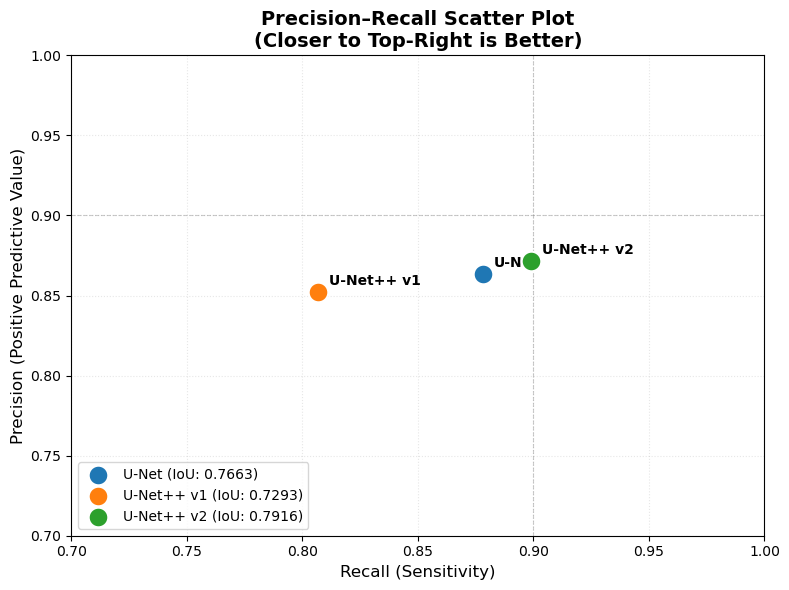

In [33]:
# Precision–Recall 산점도
# 두 모델의 IoU가 같을 때 어느 방향으로 틀렸는지 한눈에 비교 가능

# 변수 정의
MODEL_NAMES = list(all_results.keys()) 
colors_list = ['#1f77b4', '#ff7f0e', '#2ca02c'] 

# 산점도 그리기
fig, ax = plt.subplots(figsize=(8, 6))

for name, color in zip(MODEL_NAMES, colors_list):
    recall = all_results[name]['recall']
    precision = all_results[name]['precision']
    iou = all_results[name]['iou']
    
    ax.scatter(recall, precision, label=f"{name} (IoU: {iou:.4f})", 
               color=color, s=200, edgecolors='white', linewidth=1.5, zorder=5)
    
    ax.annotate(name, 
                xy=(recall, precision), 
                xytext=(8, 5), 
                textcoords='offset points', 
                fontsize=10, 
                fontweight='bold')

# 레이블 및 제목 영어로 변경 (경고 방지)
ax.set_xlabel('Recall (Sensitivity)', fontsize=12)
ax.set_ylabel('Precision (Positive Predictive Value)', fontsize=12)
ax.set_title('Precision–Recall Scatter Plot\n(Closer to Top-Right is Better)', fontsize=14, fontweight='bold')

# 축 범위 설정 (차이를 잘 보기 위해 0.7~1.0 사이로 조정)
ax.set_xlim(0.7, 1.0) 
ax.set_ylim(0.7, 1.0)

# 가이드 라인 (0.9 지점 표시)
ax.axhline(0.9, color='gray', linestyle='--', linewidth=0.8, alpha=0.4)
ax.axvline(0.9, color='gray', linestyle='--', linewidth=0.8, alpha=0.4)

ax.legend(loc='lower left')
ax.grid(True, linestyle=':', alpha=0.3)
plt.tight_layout()

# 그래프 저장
save_path = os.path.join(SAVE_DIR, 'precision_recall_analysis.png')
plt.savefig(save_path, dpi=150)
plt.show()

- **U-Net++ v2** 모델은 Recall(0.90)과 Precision(0.87) 모두 우수하며 산점도에서 가장 우상단에 위치해 종합적인 도로 검출 성능이 가장 강력함을 증명했다.

- **U-Net** 모델은 구조가 가장 단순함에도 불구하고 v1보다 높은 IoU(0.77)를 기록했다.

- **U-Net++ v1**은 경계선(Boundary IoU)에 강점이 있으나 전체적인 누락이 잦은 반면, v2는 학습 후반부까지 Validation Loss가 소폭 요동치면서도 결국 가장 정밀한 예측을 해냈다.

### 5-3. 정성적 평가

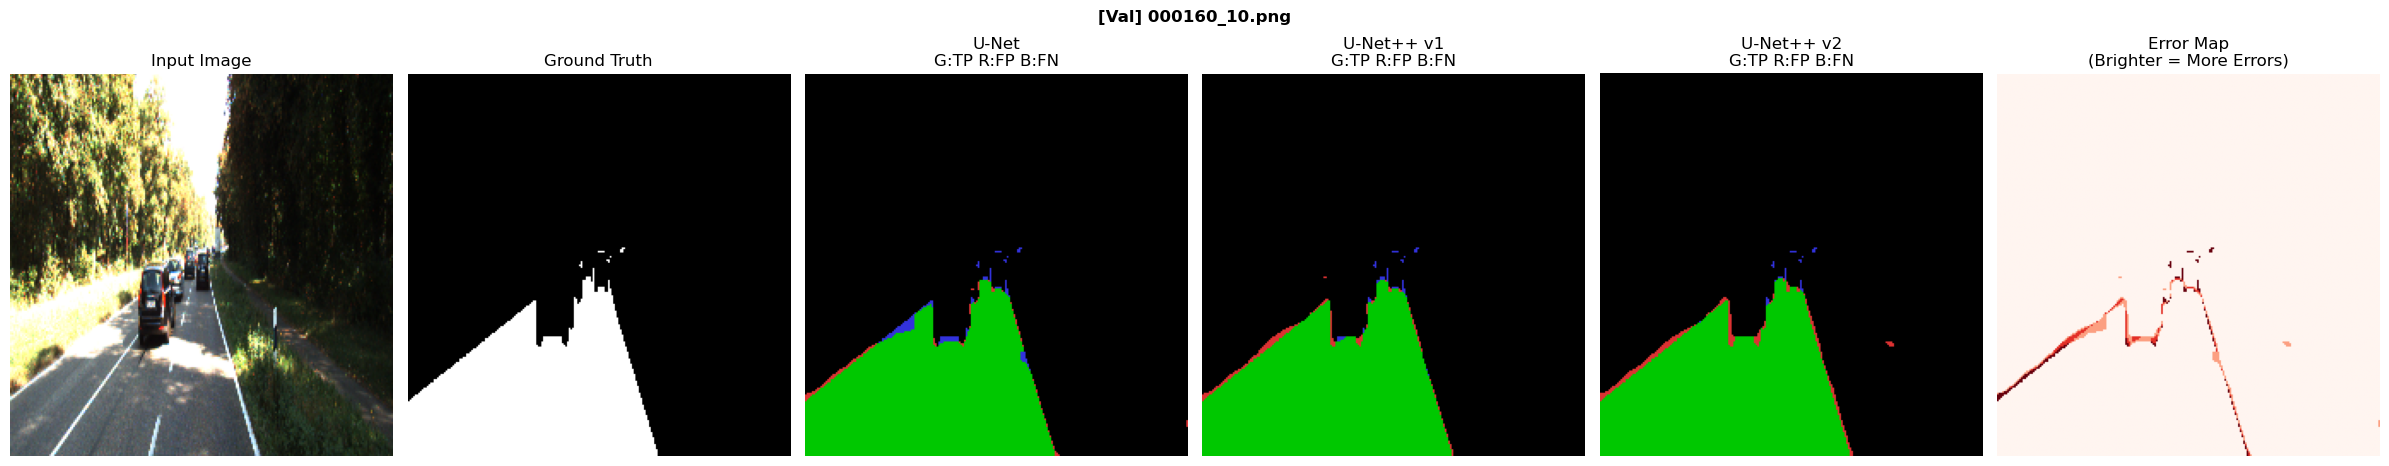

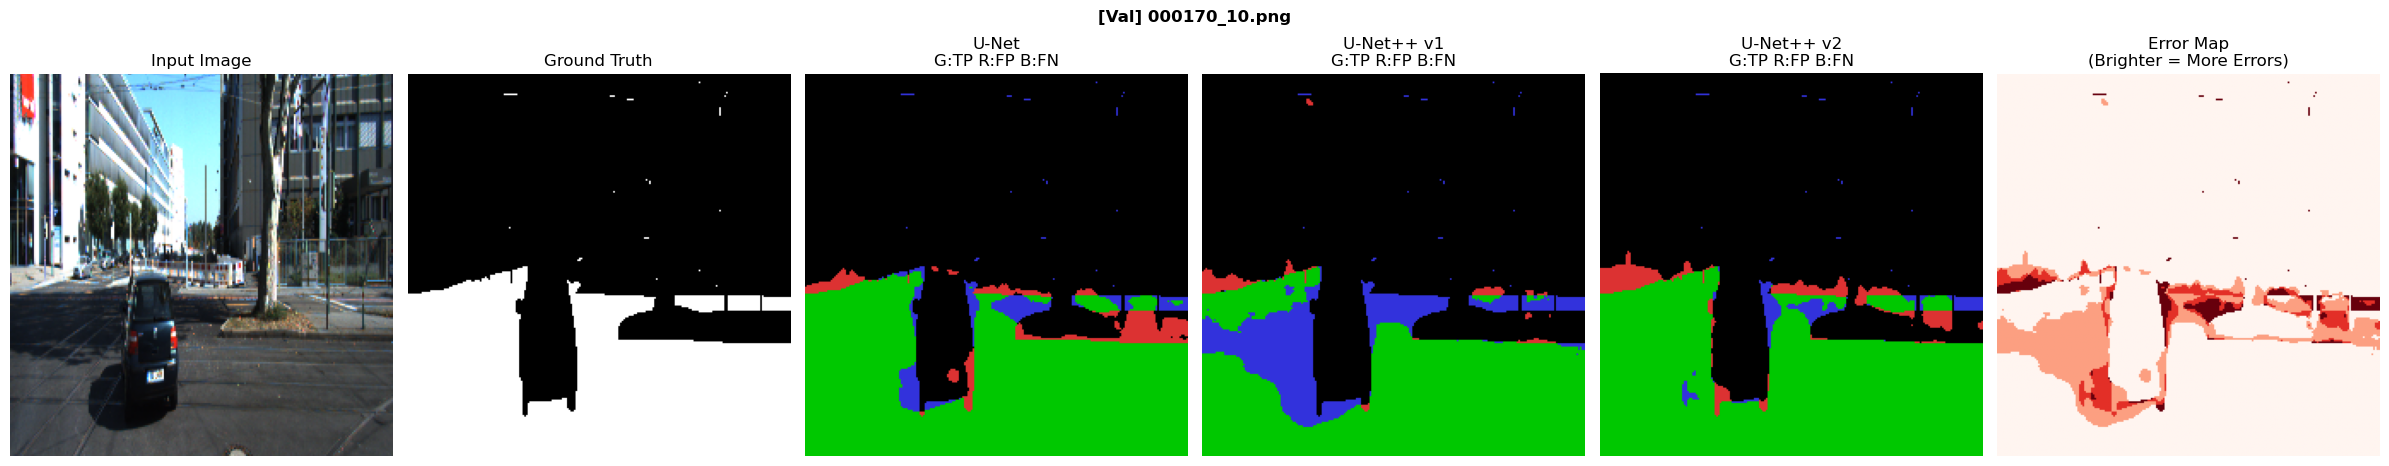

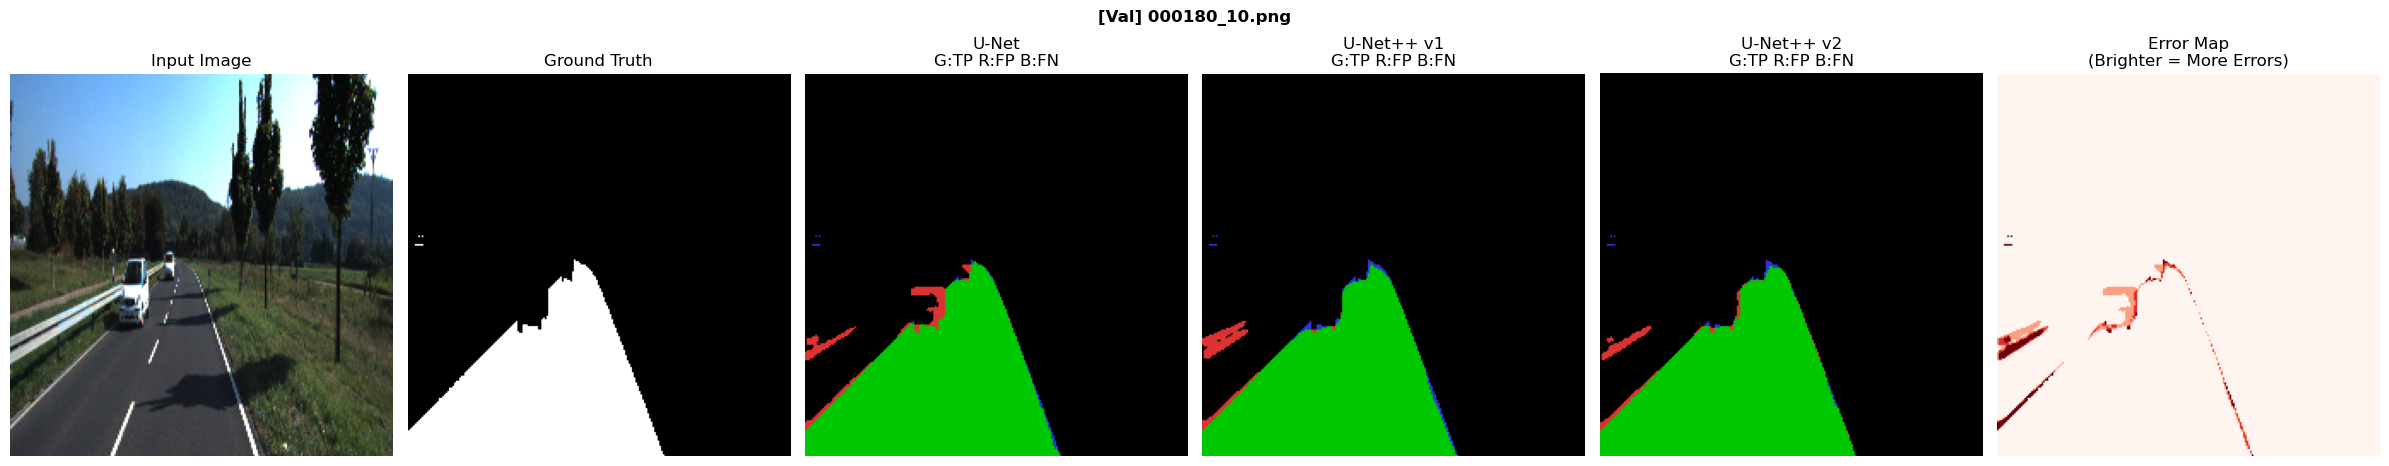

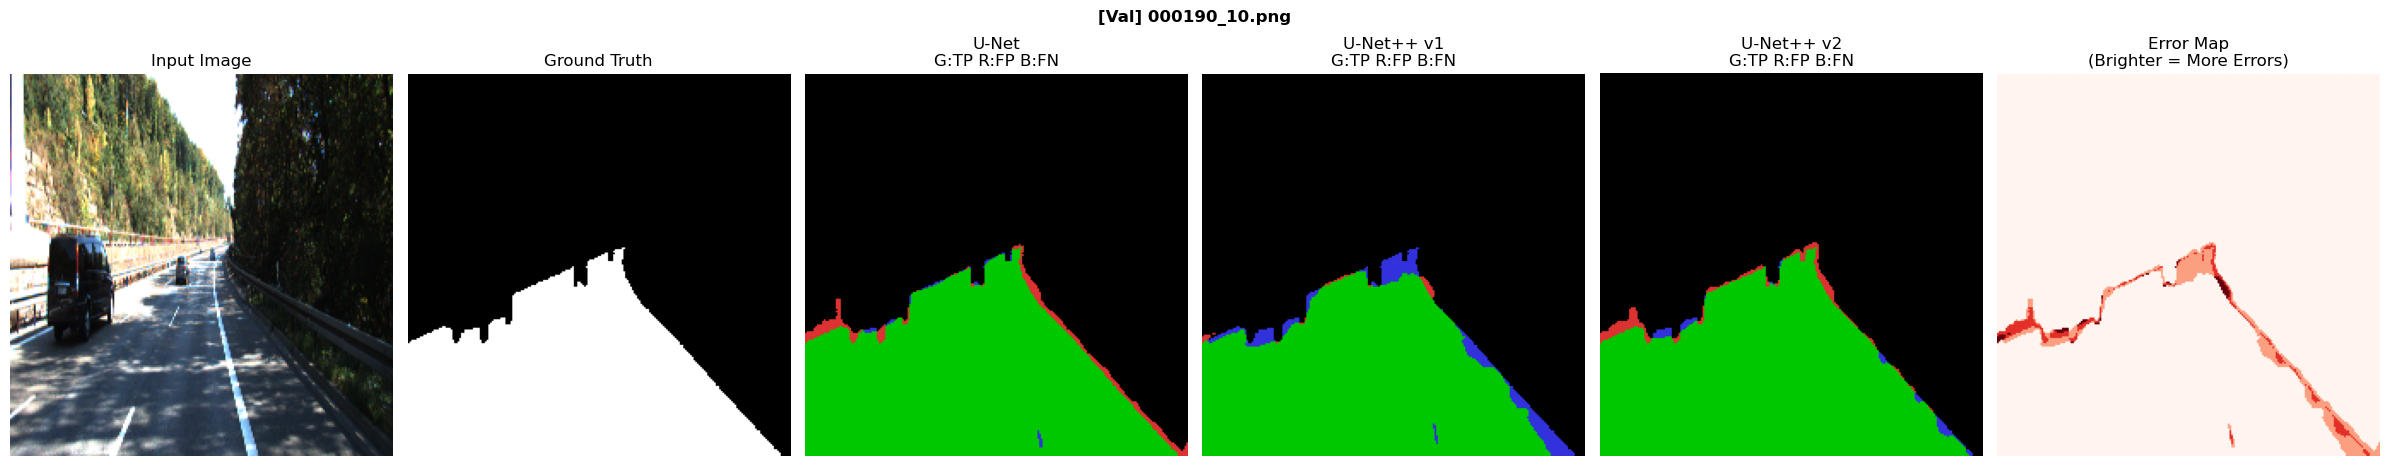

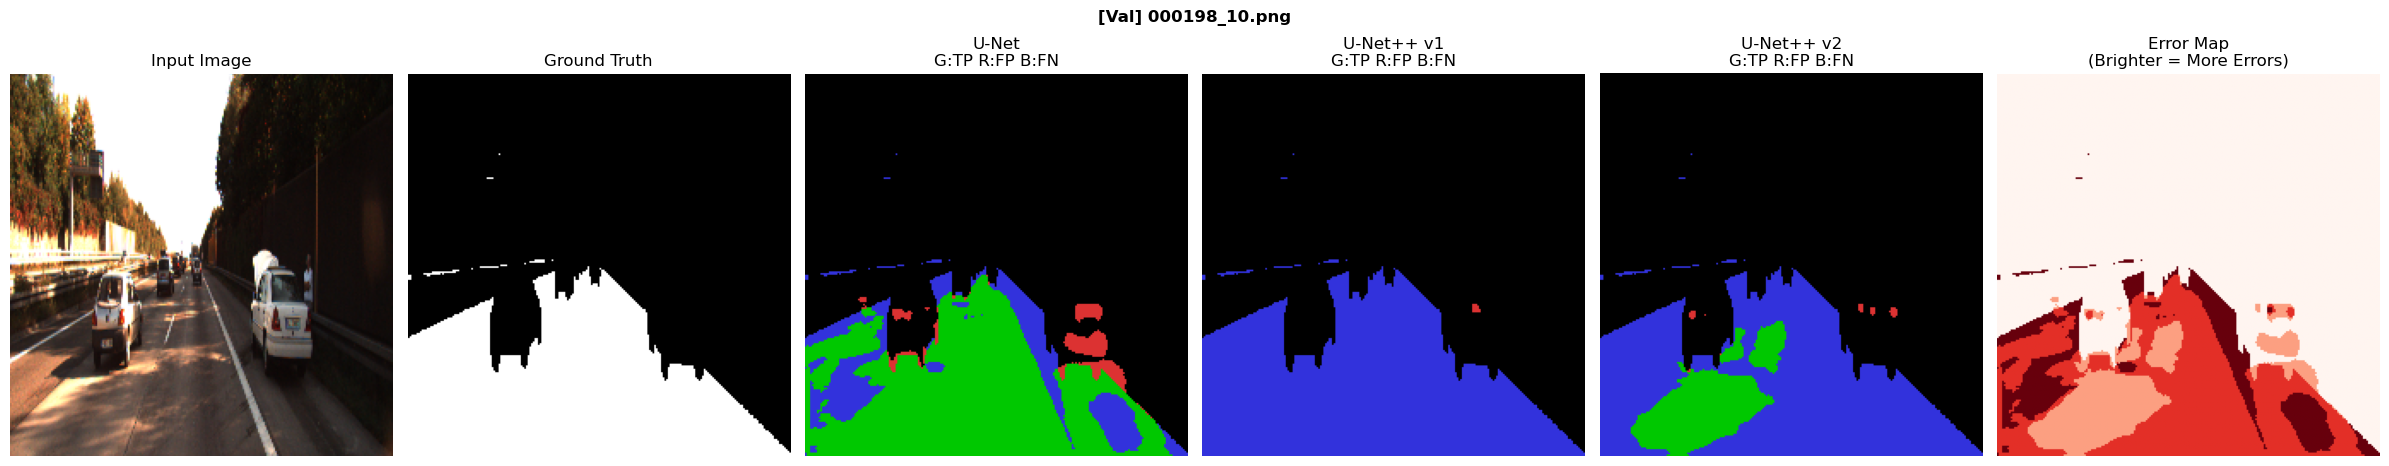

In [37]:
# [Val set 이용] Ground Truth 비교 및 오류 맵 시각화

def visualize_with_gt(models_list, val_dataset, preproc, save_dir, vis_indices=None):
    if vis_indices is None:
        n = len(val_dataset.data)
        # 마지막 index 에러 방지를 위해 min 처리
        vis_indices = [int(n * r) for r in [0.0, 0.25, 0.5, 0.75, 0.95]]

    for idx in vis_indices:
        img_path, label_path = val_dataset.data[idx]
        img_name = os.path.basename(img_path)
        origin_img = imread(img_path)

        # GT 로드 및 이진화
        label_img = imread(label_path)
        target = preproc(image=label_img)["image"]
        if target.ndim == 3:
            target = target[:, :, 0]
        target = (target == 7).astype(np.uint8)

        preds = {}
        for m, name, key in models_list:
            # 1. 모델의 위치(CPU/GPU) 파악
            device = next(m.parameters()).device
            
            # 2. 텐서 생성 후 해당 장치로 이동 (.to(device))
            input_tensor = torch.tensor(
                preproc(image=origin_img)["image"] / 255.0, dtype=torch.float32
            ).permute(2, 0, 1).unsqueeze(0).to(device)
            
            m.eval()
            with torch.no_grad():
                out = m(input_tensor)
            
            if isinstance(out, list):
                out = out[-1]
            
            # 3. CPU로 옮긴 후 넘파이 변환 (.cpu() 추가)
            preds[name] = (out.cpu().squeeze().numpy() > 0.5).astype(np.uint8)

        # 시각화 부분
        fig, axes = plt.subplots(1, 6, figsize=(24, 5))
        fig.suptitle(f"[Val] {img_name}", fontsize=12, fontweight='bold')

        # 원본 & GT
        axes[0].imshow(preproc(image=origin_img)["image"]); axes[0].set_title("Input Image"); axes[0].axis('off')
        axes[1].imshow(target, cmap='gray', vmin=0, vmax=1); axes[1].set_title("Ground Truth"); axes[1].axis('off')

        # 모델별 예측 오버레이
        for ax, (_, name, _) in zip(axes[2:5], models_list):
            pred = preds[name]
            overlay = np.zeros((*target.shape, 3), dtype=np.uint8)
            overlay[np.logical_and(pred == 1, target == 1)] = [0, 200, 0]    # TP: Green
            overlay[np.logical_and(pred == 1, target == 0)] = [220, 50, 50]  # FP: Red
            overlay[np.logical_and(pred == 0, target == 1)] = [50, 50, 220]  # FN: Blue
            ax.imshow(overlay)
            ax.set_title(f"{name}\nG:TP R:FP B:FN"); ax.axis('off')

        # 통합 오류 맵
        error_sum = sum((preds[name] != target).astype(np.uint8) for _, name, _ in models_list)
        im_err = axes[5].imshow(error_sum, cmap='Reds', vmin=0, vmax=3)
        axes[5].set_title("Error Map\n(Brighter = More Errors)"); axes[5].axis('off')
        
        plt.tight_layout()
        save_path = os.path.join(save_dir, f'val_comparison_{img_name}')
        plt.savefig(save_path, dpi=150)
        plt.show()

# 실행
visualize_with_gt(models_to_eval, val_dataset, augmentation_val, SAVE_DIR)

- **U-Net++ v2:** 가장 높은 Recall 수치를 증명하듯 이미지 속 파란색(미검출) 영역이 거의 없이 도로를 꽉 채워 검출하지만, 낮은 Boundary IoU 탓에 에러 맵 상에서 경계선이 다소 뭉툭하고 부정확하게 나타났다.

- **U-Net:** Precision과 Recall의 균형이 좋아 시각적으로도 빨간색(오검출)과 파란색(미검출)의 분포가 고르게 나타났다.

- **U-Net++ v1:** Boundary IoU(0.2686)가 가장 높아 도로의 외곽선은 날카롭게 잡아내지만, 낮은 Recall로 인해 이미지 곳곳에 도로를 인식하지 못한 파란색(미검출) 영역이 가장 넓게 나타났다.

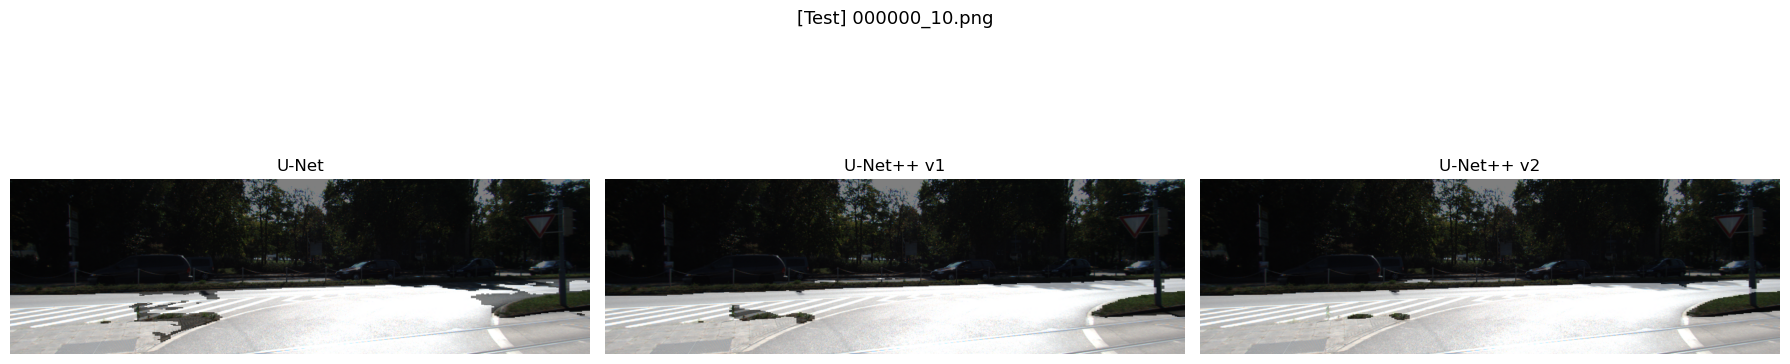

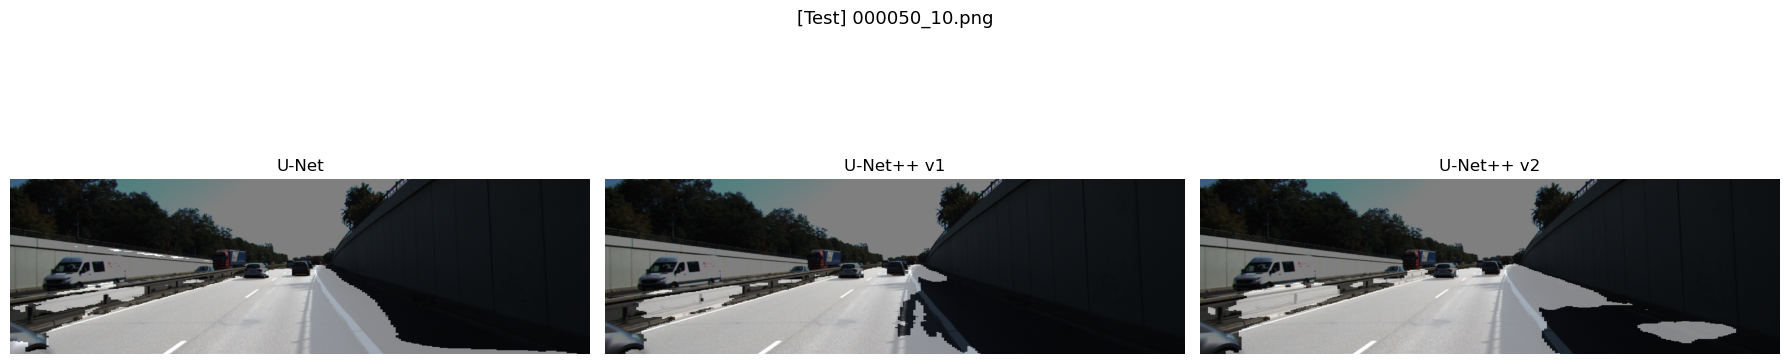

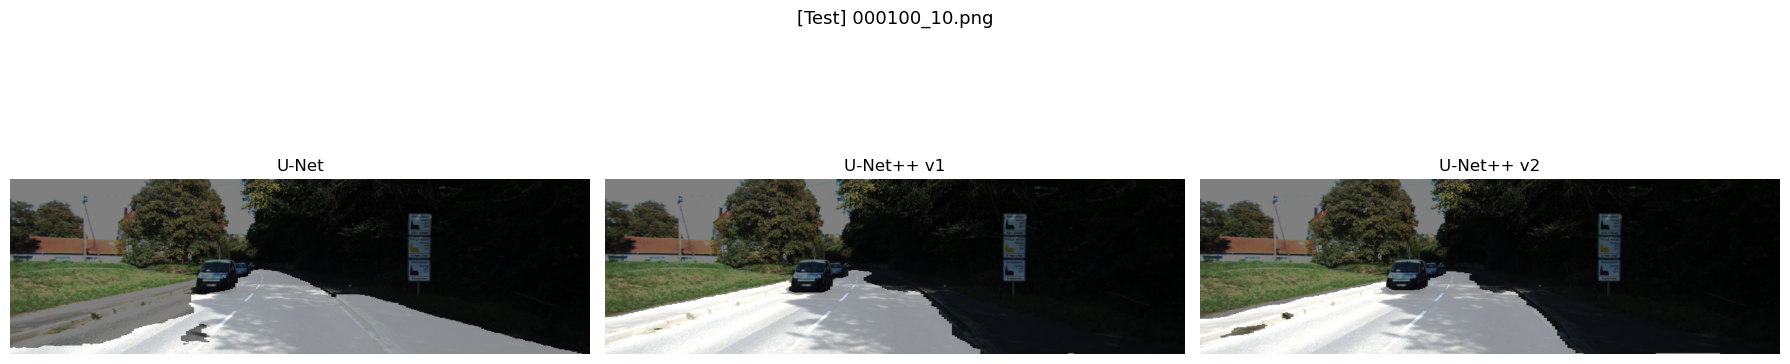

In [40]:
# [Test set 이용] Test set 오버레이 시각화 (라벨 없음)

def get_output_no_label(model, preproc, image_path, output_path):
    '''
    라벨이 없는 test 이미지에 대해 추론 후 오버레이 이미지 저장
    '''
    # 1. 모델이 있는 장치(GPU/CPU) 확인
    device = next(model.parameters()).device
    
    origin_img = imread(image_path)
    input_tensor = torch.tensor(
        preproc(image=origin_img)["image"] / 255.0, dtype=torch.float32
    ).permute(2, 0, 1).unsqueeze(0).to(device) # .to(device) 추가

    model.eval()
    with torch.no_grad():
        output = model(input_tensor)
        
    if isinstance(output, list):
        output = output[-1]

    # 2. .cpu()를 추가하여 Numpy 변환 에러 방지
    prediction = (output.cpu().squeeze().numpy() > 0.5).astype(np.uint8)
    
    # PIL 변환 및 시각화 처리
    pred_vis = Image.fromarray(prediction * 255).convert('L')
    background = Image.fromarray(origin_img).convert('RGBA')
    
    # 예측 마스크 크기를 원본 이미지에 맞게 조정
    pred_resized = pred_vis.resize((origin_img.shape[1], origin_img.shape[0]), resample=Image.NEAREST).convert('RGBA')
    
    # 3. 도로 영역만 색상을 넣고 싶다면 마스크 처리 가능
    blended = Image.blend(background, pred_resized, alpha=0.5)
    blended.save(output_path)

    return np.array(blended)


# test set에서 시각화할 이미지 인덱스 (변경 가능)
TEST_VIS_IDX = [0, 50, 100]

for vis_idx in TEST_VIS_IDX:
    if vis_idx >= len(test_dataset.data):
        print(f"인덱스 {vis_idx} 는 test set 범위 초과 — skip")
        continue

    test_img_path, _ = test_dataset.data[vis_idx]
    img_name = os.path.basename(test_img_path)

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f"[Test] {img_name}", fontsize=13)

    for ax, (m, name, key) in zip(axes, models_to_eval):
        save_path  = os.path.join(SAVE_DIR, f'test_result_{key}_{img_name}')
        blended_np = get_output_no_label(m, augmentation_val, test_img_path, save_path)
        ax.imshow(blended_np); ax.set_title(name); ax.axis('off')

    plt.tight_layout()
    comparison_path = os.path.join(SAVE_DIR, f'test_comparison_{img_name}')
    plt.savefig(comparison_path, dpi=150)
    plt.show()

- **U-Net:**

  * 횡단보도의 흰색 패턴과 도로 배경 사이 어두운 부분을 도로가 아니라고 판단해 3개 모델 중 가장 큰 구멍이 있는 마스크를 출력했고, 노면 표시가 복잡한 교차로 입구 등에서는 경계가 소폭 번지기도 했다.
  
  * 음영 및 저조도 환경에서는 도로인 부분을 탐지하지 못하거나, 인도를 도로라고 인식해 침범했다.


- **U-Net++ v1**:

  * 역시나 마스크의 횡단보도 근체에 구멍이 생겼다. 또한 가로수 근처의 경계가 울퉁불퉁하다.
 
  * 음영이 있을 때의 인도와 도로 구분은 U-Net보다 정확했으나 역시 경계가 불분명했다.

- **U-Net++ v2:**

  * 복잡한 노면 패턴에 관계없이 도로 전체를 하나의 거대한 영역으로 취급해 가장 확실한 마스크를 생성했다.
 
  * 인도를 세 모델 중 가장 정확하게 구분했으며 어두운 음영 속에서도 노면의 질감을 잘 파악하여 최고의 검출율 보였다. 하지만 그림자 경계를 따라 마스크 테두리가 울퉁불퉁해진 것은 어쩔 수 없었다.

In [41]:
# 성능 vs. 추론 속도 trade-off 비교
def measure_inference_speed(model, preproc, sample_img_path):
    device = next(model.parameters()).device
    model.eval()
    
    # 더미 입력 생성 (실제 이미지 크기 기준)
    img = imread(sample_img_path)
    dummy_input = torch.randn(1, 3, 224, 224).to(device) # 사용 중인 입력 사이즈로 조절
    
    # Warm-up (GPU 예열)
    for _ in range(10):
        _ = model(dummy_input)
    
    # 측정 시작
    start_time = time.time()
    iterations = 100
    with torch.no_grad():
        for _ in range(iterations):
            _ = model(dummy_input)
            if device.type == 'cuda':
                torch.cuda.synchronize() # GPU 연산 완료 대기
                
    end_time = time.time()
    fps = iterations / (end_time - start_time)
    return fps

# 측정 실행
print("\n[Inference Speed Test]")
for m, name, _ in models_to_eval:
    fps = measure_inference_speed(m, augmentation_val, test_dataset.data[0][0])
    print(f" * {name:12}: {fps:.2f} FPS")


[Inference Speed Test]
 * U-Net       : 23.26 FPS
 * U-Net++ v1  : 8.60 FPS
 * U-Net++ v2  : 8.51 FPS


FPS는 Frames Per Second의 약자로 모델이 1초 동안 처리할 수 있는 이미지 장수를 의미한다.

- 24 FPS 이상이 우리가 영화를 볼 때 끊김이 없다고 느끼는 속도라고 한다. **U-Net** 모델만이 도로 주행 시 카메라로 들어오는 영상을 **실시간으로** 분석할 수 있음을 의미한다.

- U-Net++ v1과 U-Net++ v2은 1초에 8장만 처리 가능하다. 만약 시속 100km로 달리는 차라면 모델이 한 장을 분석하는 사이 차는 이미 수 미터를 지나가 버려 위험 상황에 제대로 대응을 할 수 없을지도 모른다.

## 결론

**실제 자율주행 차량에는 어떤 모델을 적용해야 할까?**

모델이 복잡해지면 정확도는 올라가지만 계산량이 많아져 FPS가 떨어지는 현상을 관찰할 수 있었다.

실제 상황에서는 무조건 가장 똑똑한 모델이 좋을지, 아니면 적당히 똑똑하면서 추론 속도가 빠른 모델이 좋을지 trade-off를 고려해 결정을 내려야 할 듯하다.

해서 정확도는 다른 두 모델에 비해 떨어지지만, Recall과 Precision, F1, IoU, Boundary IoU 등이 심각하게 낮지 않고 속도가 3배 정도 빠른 U-Net이 적절하지 않을까 한다.

## 회고

- 라벨 없는 테스트 데이터셋을 평가에 활용하는 방법과 모델 선택 기준에 대해 고민해볼 수 있었던 시간이었다.

- <4-4 학습 곡선 확인>에서 3개 모델 전부 에폭을 100으로 설정하지 않아도 되겠다는 깨달음을 얻었다. 실무에서는 큰 시간 낭비로 이어질 수 있는 부분인 만큼 에폭을 무조건 늘리기 보다 학습 수렴을 중점으로 횟수를 설정해야겠다.

- 실제 자율주행에서는 도로가 아닌 영역을 도로로 인식하는 것과 도로를 도로가 아닌 영역이라고 인식하는 것 중 어느 걸 더 위험하다고 보는지 (혹은 둘 다 놓치면 안되는지) 궁금하다.

- Boundary IoU 지표가 특히 낮았는데, 어떻게 하면 도로와 비도로의 경계를 정확하게 탐지하게 할 수 있을지 고민이 더 필요하다.

- 참고 문헌:

  * [Zhou, Z., et al. (2018) [UNet++ v1]](https://arxiv.org/pdf/1807.10165)
 
  * [Zhou, Z., et al. (2019) [UNet++ v2]](https://arxiv.org/pdf/1912.05074)